<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=310543089" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106546,2026-04-04,0002098712,2025-12-31,0.000156,0.000000,NaN,NaN,-0.000020,-0.000004,0.000078,...,NaN,NaN,NaN,NaN,NaN,GIX,NASDAQ,0.000000,NaN,94
1106547,2026-04-04,0002099093,2025-12-31,0.000344,NaN,NaN,NaN,-0.000020,-0.000010,0.000011,...,NaN,NaN,NaN,NaN,NaN,HCIC,NASDAQ,0.241500,NaN,94
1106548,2026-04-04,0002099656,2025-12-31,0.000307,NaN,NaN,NaN,-0.000026,NaN,0.000025,...,NaN,NaN,NaN,NaN,NaN,HLXC,NASDAQ,0.169270,NaN,94
1106549,2026-04-04,0002099906,2025-12-31,0.000391,NaN,NaN,NaN,-0.000075,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,AACO,NASDAQ,0.000000,NaN,94


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)

# There are 100+ ciks that report too infrequently, i.e. less than 4 times a year.
# These are mostly foreign (non-US) entities that nevertheless trade on US exchanges.
# Whatever the cause, ciks that report less often than 4 times a year distort the model and we
# remove them. We determine the reporting frequency by the unique Asset values reported per year.
too_few_reports = snapshots[['Assets']].dropna()
too_few_reports['year'] = pd.to_datetime(too_few_reports.index.get_level_values(0)).year
too_few_reports = too_few_reports.groupby(by=['cik','year'])['Assets'].nunique().groupby('cik').max()
too_few_reports = snapshots.loc[(slice(None),too_few_reports[too_few_reports<4].index),:].index
snapshots = snapshots.drop(index=too_few_reports)

snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-04-04 0001905956 2025-12-31    TGL   0.024230     0.006274   
           0001906324 2025-12-28   QDEL   5.769300     3.848800   
           0001907982 2025-12-31   QBTS   0.915813     0.063583   
           0001914605 2025-12-31   ECBK   1.605653     1.433719   
           0001915657 2025-12-31   DINO  16.510000     7.326000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-04-04 0001905956 2025-12-31             -0.012631    NaN  
           0001906324 2025-12-28              0.105200    NaN  
           0001907982 2025-12-31             -0.071982    NaN  
           0001914605 2025-12-31              0.009220    NaN  
           0001915657 2025-12-31              1.315000    NaN  

[439221 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3147 unique ciks for a total of 531843 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[531843 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [9]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [10]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3147, 169, 3])
Labels shape: torch.Size([3147, 169])
Asset multiplier shape: torch.Size([3147])
Cash multiplier shape: torch.Size([169])


device(type='cpu')

Adjusted assets shape: torch.Size([3147, 169])
Adjusted cashflow shape: torch.Size([3147, 169])
Forward shape: torch.Size([3147, 169])
Epoch [1000/6000], Loss=916.06158958
Epoch [2000/6000], Loss=915.19810104
Epoch [3000/6000], Loss=915.17587497
Epoch [4000/6000], Loss=915.23367554
Epoch [5000/6000], Loss=915.07939471
Epoch [6000/6000], Loss=915.03957236


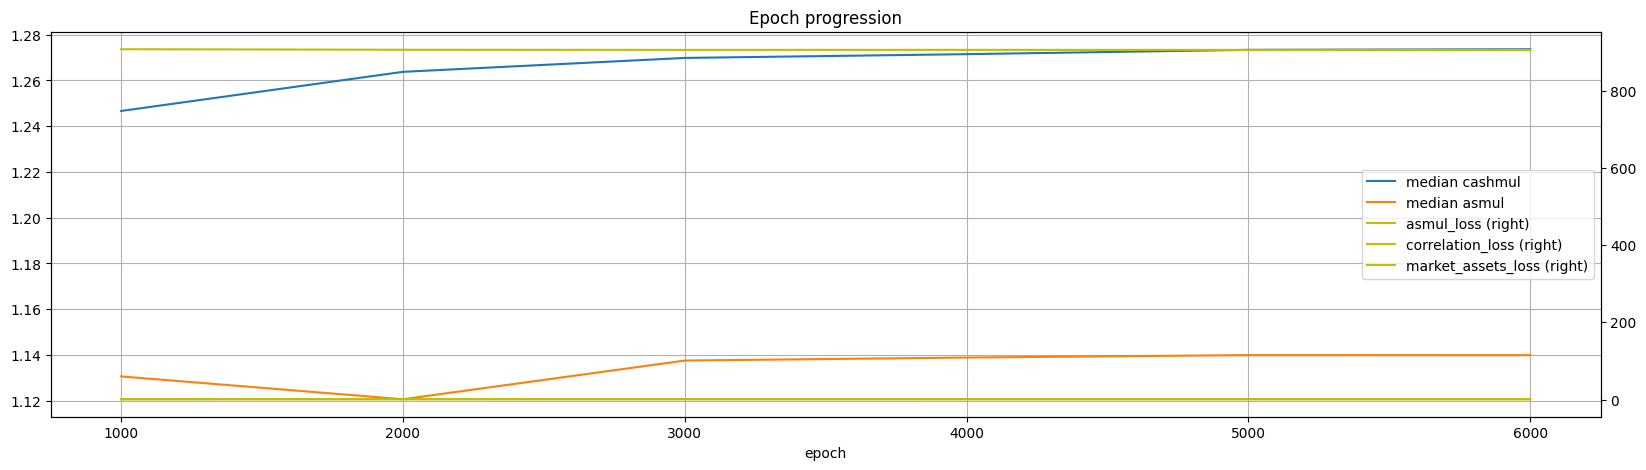

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.246669,1.130565,0.831363,906.853200,0.894762
2000,1.263779,1.120592,0.879998,905.466467,0.931656
3000,1.269863,1.137506,0.894691,905.143284,1.085684
4000,1.271505,1.138822,0.912691,905.199444,0.907323
5000,1.273395,1.139880,0.909322,905.110999,0.875177
6000,1.273671,1.139874,0.910408,905.048777,0.886719


In [11]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [12]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  1.005550 -1.175388  0.775810  
           2012-02-01  1.005550 -1.033792  0.787646  
           2012-03-01  1.005550 -0.959121  0.793887  
           2012-04-01  1.005550 -0.890643  0.842821  
           2012-05-01  1.005550 -0.914941  0.841196  
...                         ...       ...       ...  
0001915657 2025-09-01  0.820846  1.614754  7.987454  
           2025-10-01  0.820846  1.602533  7.974414  
           2025-11-01  0.820846  1.483245  8.068034  
           2025-12-01  0.820846  1.525451  8.117289  
           2026-01-01  0.820846  1.529789  8.122352  

[414387 rows x 7 columns]

In [13]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['slope'] = regressor.coef_[0]
    df['intercept'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept
snapshot,cik,date,,,,,,,,,,
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.560013,1.626712,280.408899,0.585911,49.936741
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.560013,1.552820,267.323344,0.585911,49.936741
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.560013,1.828527,356.553879,0.585911,49.936741
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.560013,1.551395,302.805991,0.585911,49.936741
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.560013,1.632107,318.459677,0.585911,49.936741
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.560013,1.547289,316.017789,0.585911,49.936741
2025-04-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,190.26,0.560013,1.374103,281.880404,0.585911,49.936741
2025-05-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,184.42,0.560013,1.285612,264.437567,0.585911,49.936741
2025-06-01,0001018724,2025-03-31,AMZN,643.256,337.389,199.102833,205.01,0.560013,1.417579,305.086917,0.585911,49.936741


Let's examine the achieved correlations using a histogram:

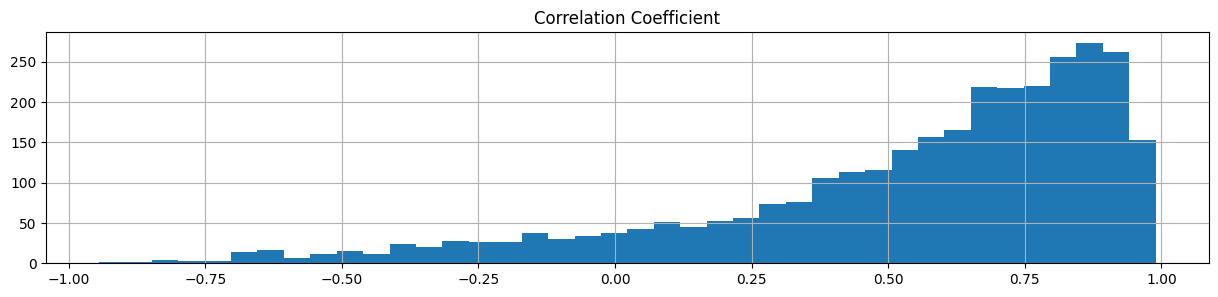

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

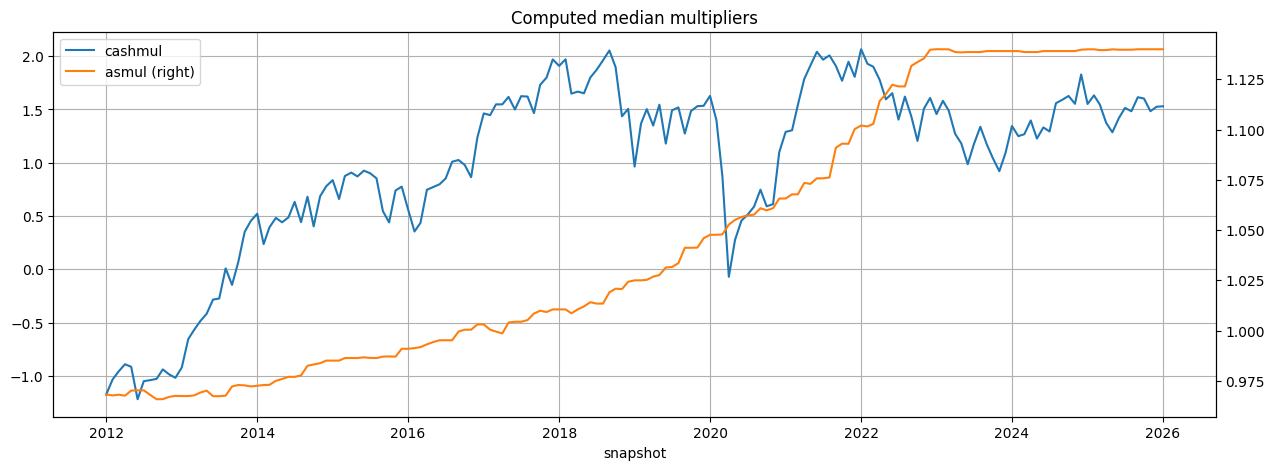

Median asset_multiplier per cik: 1.1398736238479614
Median asset_multiplier per snapshot: 1.0249888896942139


In [15]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [16]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

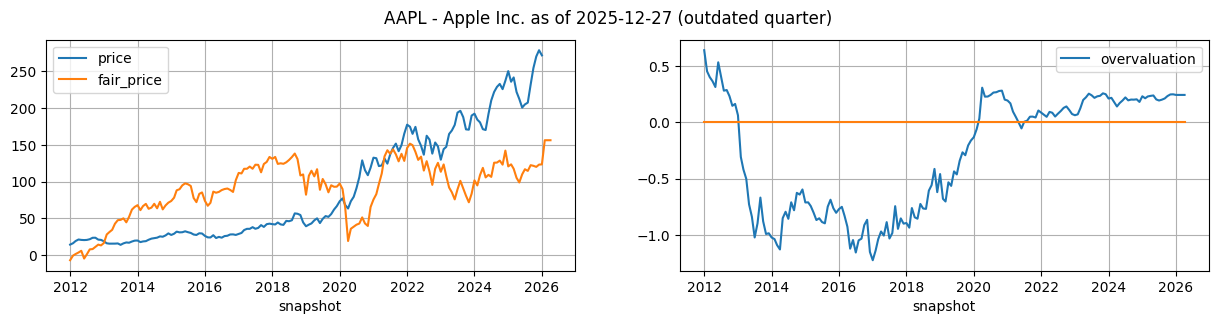

AAPL fair_price = 0.655769 * (0.946523 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -24.003594


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.946523,1.529789,0.655769,-24.003594,225.065834,123.587541,0.244826
2026-02-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,0.946523,1.529789,0.655769,-24.003594,275.149942,156.431133,0.244826
2026-03-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,0.946523,1.529789,0.655769,-24.003594,275.149942,156.431133,0.244826
2026-04-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,0.946523,1.529789,0.655769,-24.003594,275.149942,156.431133,0.244826
2026-04-04,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,0.946523,1.529789,0.655769,-24.003594,275.149942,156.431133,0.244826


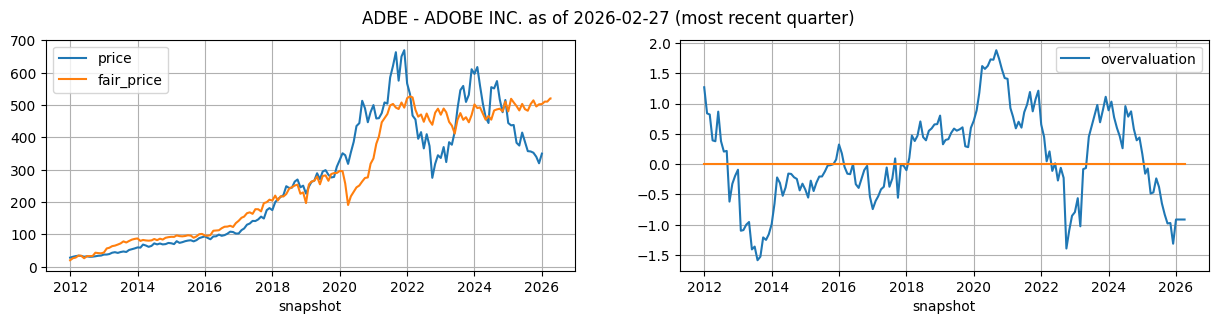

ADBE fair_price = 16.263682 * (1.341353 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -91.448235


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.341353,1.529789,16.263682,-91.448235,36.564958,503.232619,-0.913173
2026-02-01,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.341353,1.529789,16.263682,-91.448235,37.036862,510.907507,-0.913173
2026-03-01,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.341353,1.529789,16.263682,-91.448235,37.036862,510.907507,-0.913173
2026-04-01,0000796343,2026-02-27,ADBE,29.704,18.271,10.507,1.341353,1.529789,16.263682,-91.448235,37.646043,520.815034,-0.913173
2026-04-04,0000796343,2026-02-27,ADBE,29.704,18.271,10.507,1.341353,1.529789,16.263682,-91.448235,37.646043,520.815034,-0.913173


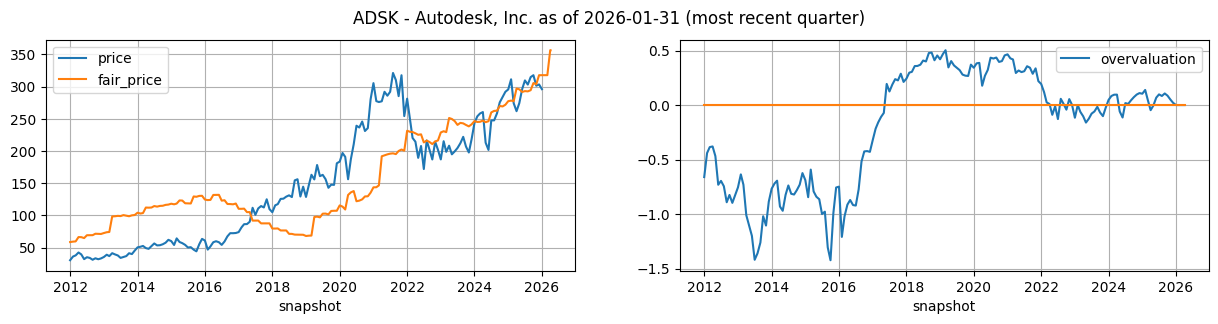

ADSK fair_price = 8.167462 * (4.258632 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -30.848490


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.258632,1.529789,8.167462,-30.84849,42.679859,317.737632,-0.0
2026-02-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.258632,1.529789,8.167462,-30.84849,42.679859,317.737632,-0.0
2026-03-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.258632,1.529789,8.167462,-30.84849,42.679859,317.737632,-0.0
2026-04-01,0000769397,2026-01-31,ADSK,12.467,9.422,2.452,4.258632,1.529789,8.167462,-30.84849,47.421411,356.464074,-0.0
2026-04-04,0000769397,2026-01-31,ADSK,12.467,9.422,2.452,4.258632,1.529789,8.167462,-30.84849,47.421411,356.464074,-0.0


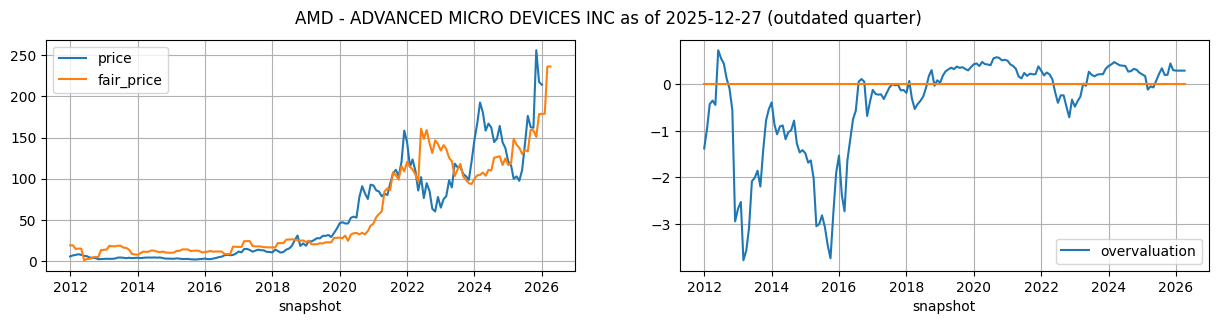

AMD fair_price = 13.780741 * (0.201356 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +52.252391


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.201356,1.529789,13.780741,52.252391,9.184319,178.819103,0.287809
2026-02-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.201356,1.529789,13.780741,52.252391,9.184319,178.819103,0.287809
2026-03-01,0000002488,2025-12-27,AMD,76.926,13.927,7.709,0.201356,1.529789,13.780741,52.252391,13.355622,236.302751,0.287809
2026-04-01,0000002488,2025-12-27,AMD,76.926,13.927,7.709,0.201356,1.529789,13.780741,52.252391,13.355622,236.302751,0.287809
2026-04-04,0000002488,2025-12-27,AMD,76.926,13.927,7.709,0.201356,1.529789,13.780741,52.252391,13.355622,236.302751,0.287809


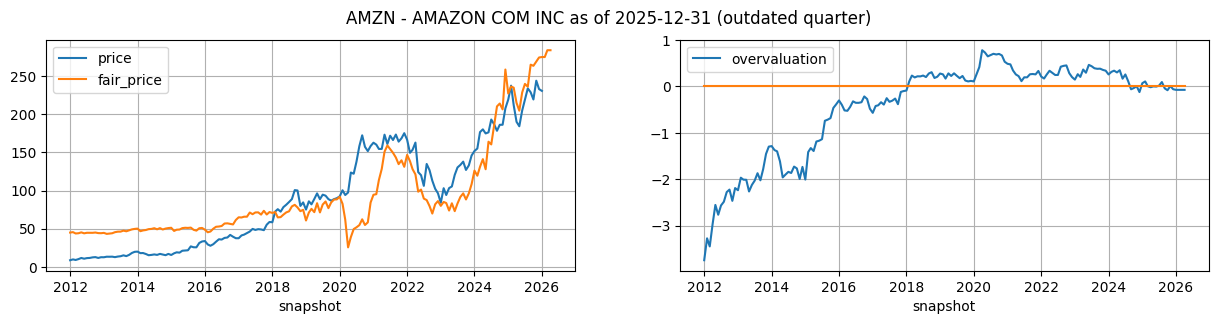

AMZN fair_price = 0.585911 * (0.560013 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.936741


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.560013,1.529789,0.585911,49.936741,384.532508,275.238525,-0.074775
2026-02-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.560013,1.529789,0.585911,49.936741,384.532508,275.238525,-0.074775
2026-03-01,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,0.560013,1.529789,0.585911,49.936741,399.811797,284.190827,-0.074775
2026-04-01,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,0.560013,1.529789,0.585911,49.936741,399.811797,284.190827,-0.074775
2026-04-04,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,0.560013,1.529789,0.585911,49.936741,399.811797,284.190827,-0.074775


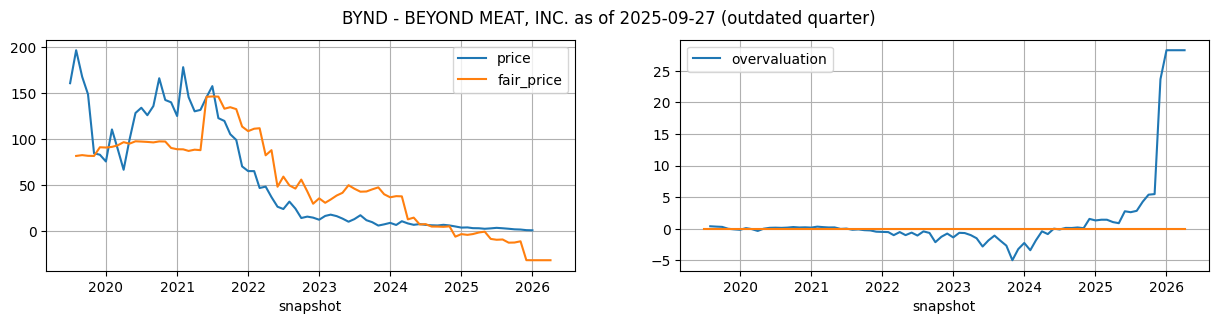

BYND fair_price = 101.638057 * (1.700699 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.053278


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,1.700699,1.529789,101.638057,25.053278,-0.558298,-31.691093,28.259413
2026-02-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,1.700699,1.529789,101.638057,25.053278,-0.558298,-31.691093,28.259413
2026-03-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,1.700699,1.529789,101.638057,25.053278,-0.558298,-31.691093,28.259413
2026-04-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,1.700699,1.529789,101.638057,25.053278,-0.558298,-31.691093,28.259413
2026-04-04,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,1.700699,1.529789,101.638057,25.053278,-0.558298,-31.691093,28.259413


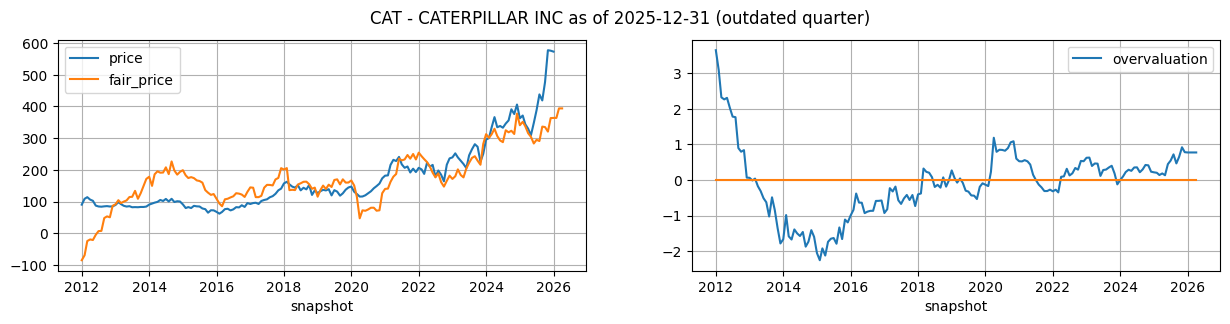

CAT fair_price = 10.507095 * (1.388991 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -421.669201


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.388991,1.529789,10.507095,-421.669201,74.771345,363.960449,0.775326
2026-02-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.388991,1.529789,10.507095,-421.669201,74.771345,363.960449,0.775326
2026-03-01,0000018230,2025-12-31,CAT,98.585,77.267,11.739,1.388991,1.529789,10.507095,-421.669201,77.624908,393.943110,0.775326
2026-04-01,0000018230,2025-12-31,CAT,98.585,77.267,11.739,1.388991,1.529789,10.507095,-421.669201,77.624908,393.943110,0.775326
2026-04-04,0000018230,2025-12-31,CAT,98.585,77.267,11.739,1.388991,1.529789,10.507095,-421.669201,77.624908,393.943110,0.775326


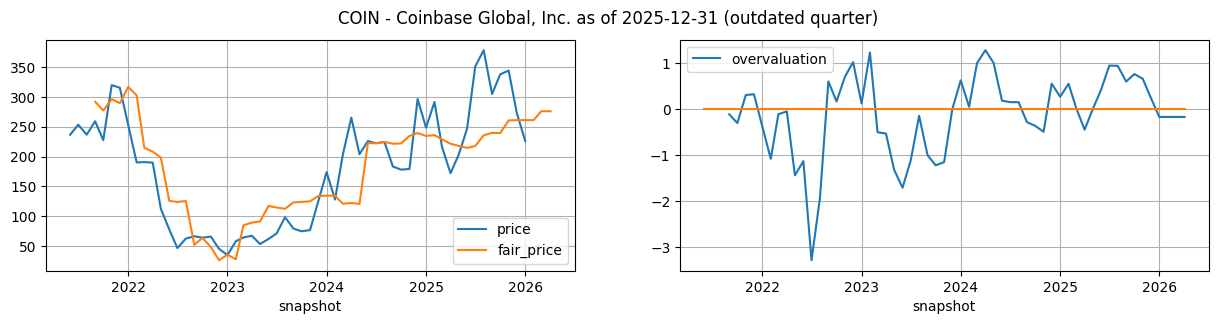

COIN fair_price = 13.287897 * (1.017602 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +22.961644


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.872941,1.017602,1.529789,13.287897,22.961644,17.910478,260.954231,-0.165902
2026-02-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.872941,1.017602,1.529789,13.287897,22.961644,17.910478,260.954231,-0.165902
2026-03-01,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,1.017602,1.529789,13.287897,22.961644,19.027188,275.792959,-0.165902
2026-04-01,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,1.017602,1.529789,13.287897,22.961644,19.027188,275.792959,-0.165902
2026-04-04,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,1.017602,1.529789,13.287897,22.961644,19.027188,275.792959,-0.165902


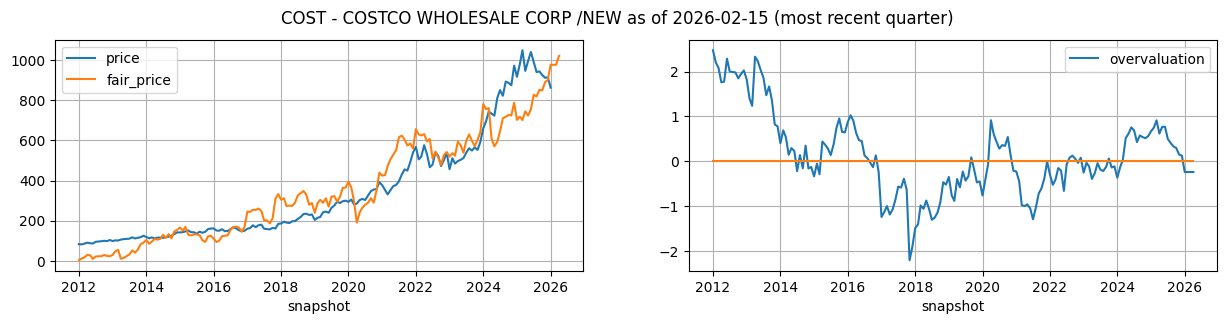

COST fair_price = 20.114193 * (1.067352 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -199.828231


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.067352,1.529789,20.114193,-199.828231,58.463355,976.114999,-0.236144
2026-02-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.067352,1.529789,20.114193,-199.828231,58.463355,976.114999,-0.236144
2026-03-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.067352,1.529789,20.114193,-199.828231,58.463355,976.114999,-0.236144
2026-04-01,0000909832,2026-02-15,COST,83.639,51.552,15.011,1.067352,1.529789,20.114193,-199.828231,60.683924,1020.779966,-0.236144
2026-04-04,0000909832,2026-02-15,COST,83.639,51.552,15.011,1.067352,1.529789,20.114193,-199.828231,60.683924,1020.779966,-0.236144


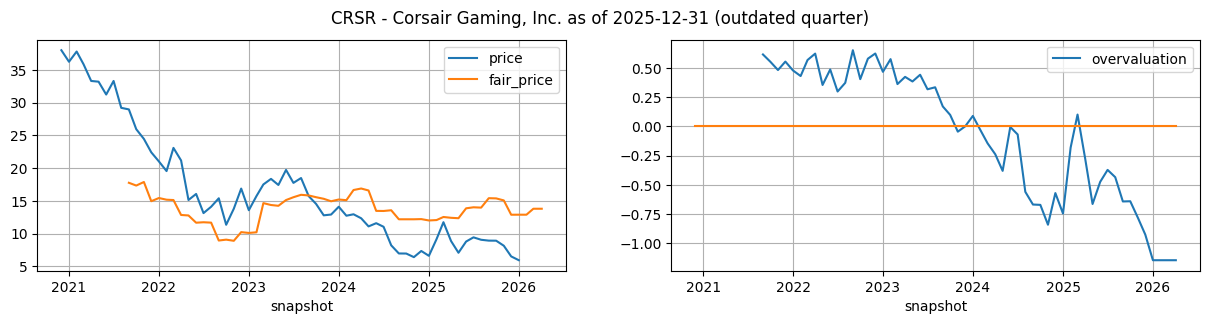

CRSR fair_price = 19.981191 * (1.700488 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.945260


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.700488,1.529789,19.981191,-17.94526,1.543035,12.886424,-1.144058
2026-02-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.700488,1.529789,19.981191,-17.94526,1.543035,12.886424,-1.144058
2026-03-01,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,1.700488,1.529789,19.981191,-17.94526,1.588492,13.794700,-1.144058
2026-04-01,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,1.700488,1.529789,19.981191,-17.94526,1.588492,13.794700,-1.144058
2026-04-04,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,1.700488,1.529789,19.981191,-17.94526,1.588492,13.794700,-1.144058


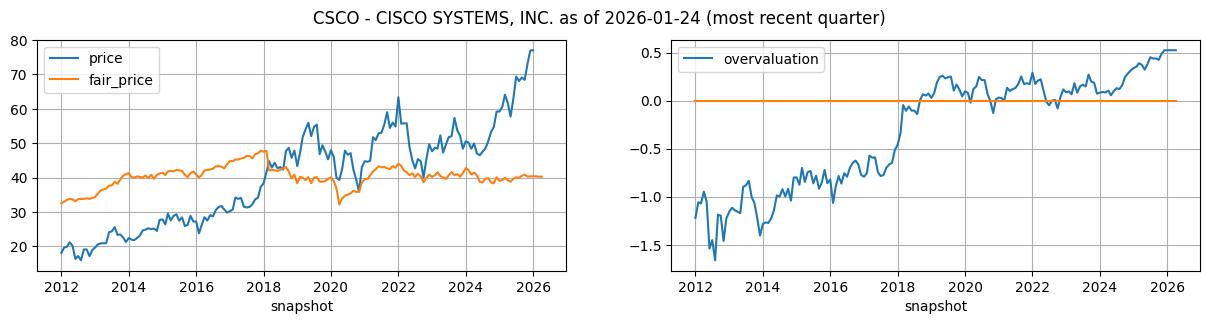

CSCO fair_price = 0.318060 * (0.750997 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.358918


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.750997,1.529789,0.31806,28.358918,37.743648,40.363676,0.523946
2026-02-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.750997,1.529789,0.31806,28.358918,37.743648,40.363676,0.523946
2026-03-01,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,0.750997,1.529789,0.31806,28.358918,37.387678,40.250456,0.523946
2026-04-01,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,0.750997,1.529789,0.31806,28.358918,37.387678,40.250456,0.523946
2026-04-04,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,0.750997,1.529789,0.31806,28.358918,37.387678,40.250456,0.523946


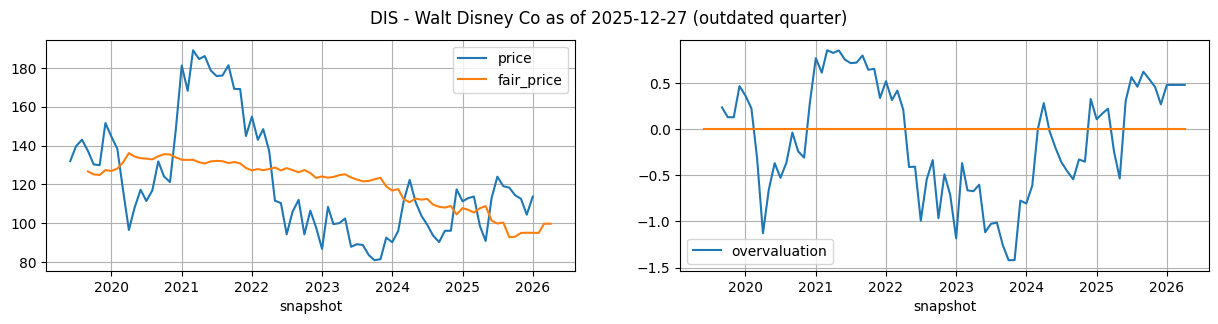

DIS fair_price = -0.845229 * (0.913512 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +196.946542


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.913511,1.529789,-0.845229,196.946542,120.476992,95.115849,0.478249
2026-02-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.913511,1.529789,-0.845229,196.946542,120.476992,95.115849,0.478249
2026-03-01,0001744489,2025-12-27,DIS,202.089,93.613,15.631,0.913511,1.529789,-0.845229,196.946542,114.909727,99.821465,0.478249
2026-04-01,0001744489,2025-12-27,DIS,202.089,93.613,15.631,0.913511,1.529789,-0.845229,196.946542,114.909727,99.821465,0.478249
2026-04-04,0001744489,2025-12-27,DIS,202.089,93.613,15.631,0.913511,1.529789,-0.845229,196.946542,114.909727,99.821465,0.478249


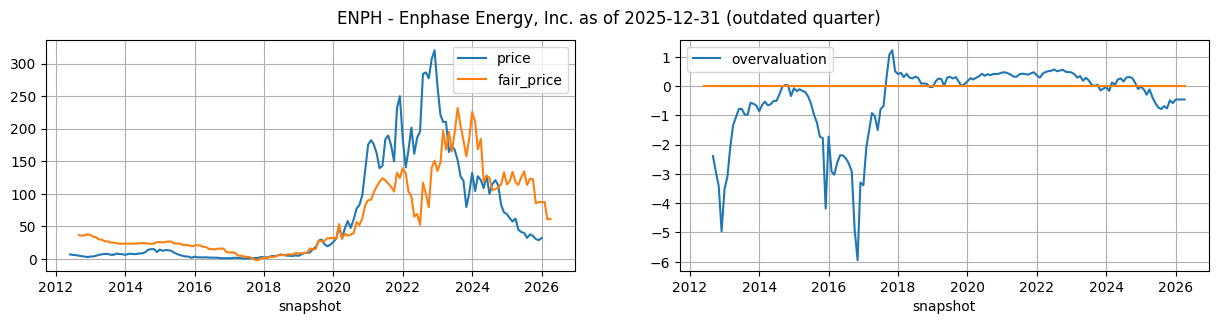

ENPH fair_price = 176.018232 * (0.692728 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +22.866866


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.692728,1.529789,176.018232,22.866866,0.366741,87.419975,-0.454991
2026-02-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.692728,1.529789,176.018232,22.866866,0.366741,87.419975,-0.454991
2026-03-01,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,0.692728,1.529789,176.018232,22.866866,0.217439,61.140007,-0.454991
2026-04-01,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,0.692728,1.529789,176.018232,22.866866,0.217439,61.140007,-0.454991
2026-04-04,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,0.692728,1.529789,176.018232,22.866866,0.217439,61.140007,-0.454991


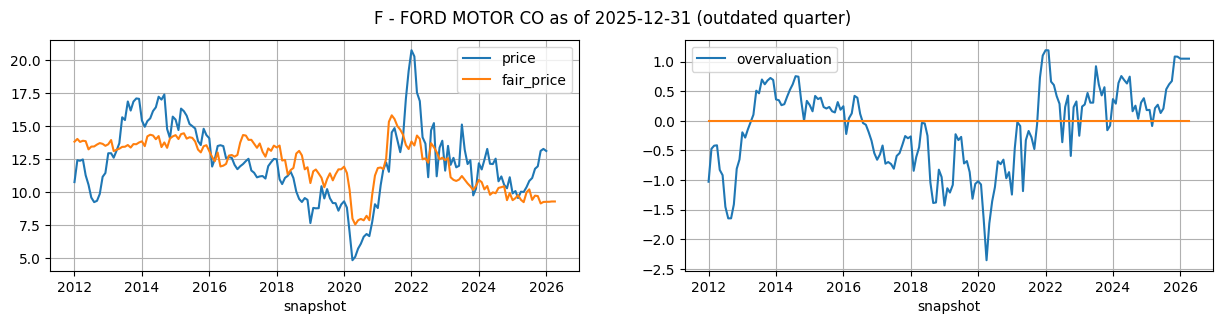

F fair_price = 0.131635 * (0.128066 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.459516


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000037996,2025-09-30,F,300.99,253.598,20.426,0.128066,1.529789,0.131635,33.459516,-183.803899,9.264459,1.049751
2026-02-01,0000037996,2025-09-30,F,300.99,253.598,20.426,0.128066,1.529789,0.131635,33.459516,-183.803899,9.264459,1.049751
2026-03-01,0000037996,2025-12-31,F,289.16,253.208,21.282,0.128066,1.529789,0.131635,33.459516,-183.619422,9.288743,1.049751
2026-04-01,0000037996,2025-12-31,F,289.16,253.208,21.282,0.128066,1.529789,0.131635,33.459516,-183.619422,9.288743,1.049751
2026-04-04,0000037996,2025-12-31,F,289.16,253.208,21.282,0.128066,1.529789,0.131635,33.459516,-183.619422,9.288743,1.049751


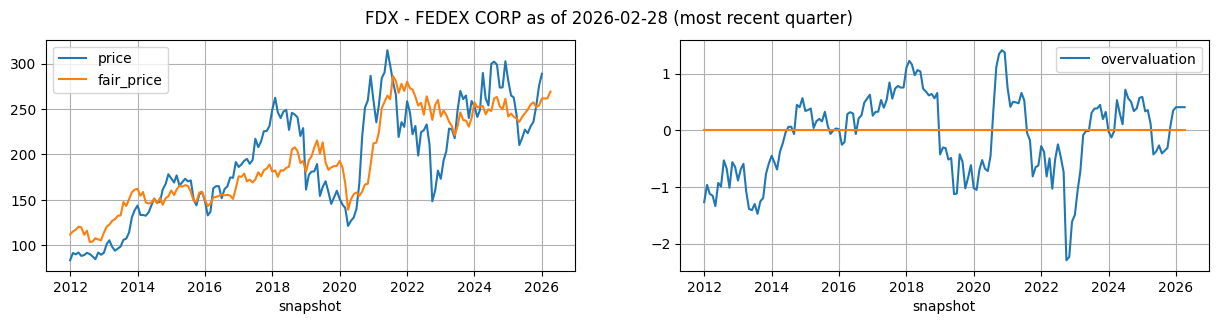

FDX fair_price = 5.852128 * (0.932842 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +58.687678


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.932842,1.529789,5.852128,58.687678,34.692022,261.709838,0.408491
2026-02-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.932842,1.529789,5.852128,58.687678,34.692022,261.709838,0.408491
2026-03-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.932842,1.529789,5.852128,58.687678,34.692022,261.709838,0.408491
2026-04-01,0001048911,2026-02-28,FDX,94.733,64.929,8.179,0.932842,1.529789,5.852128,58.687678,35.954097,269.095660,0.408491
2026-04-04,0001048911,2026-02-28,FDX,94.733,64.929,8.179,0.932842,1.529789,5.852128,58.687678,35.954097,269.095660,0.408491


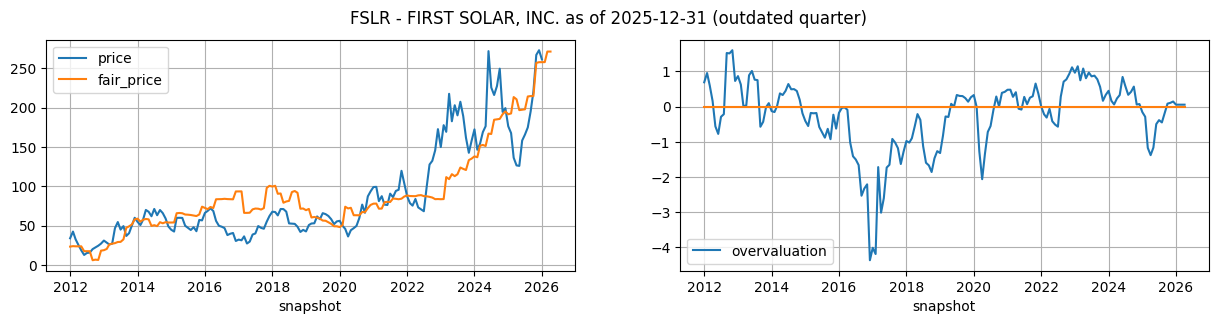

FSLR fair_price = 13.343311 * (2.266468 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -123.149874


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.266467,1.529789,13.343311,-123.149874,28.548843,257.786221,0.053183
2026-02-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.266467,1.529789,13.343311,-123.149874,28.548843,257.786221,0.053183
2026-03-01,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,2.266467,1.529789,13.343311,-123.149874,29.555934,271.224155,0.053183
2026-04-01,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,2.266467,1.529789,13.343311,-123.149874,29.555934,271.224155,0.053183
2026-04-04,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,2.266467,1.529789,13.343311,-123.149874,29.555934,271.224155,0.053183


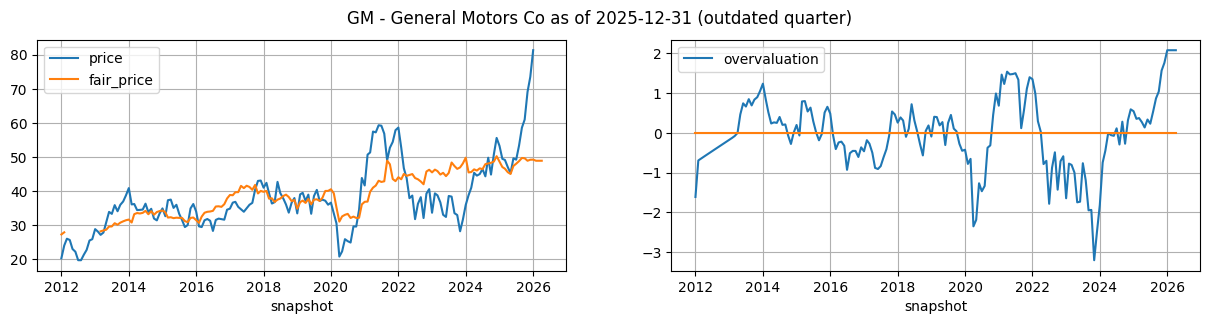

GM fair_price = 0.292959 * (0.989867 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +19.783162


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.989867,1.529789,0.292959,19.783162,100.493293,49.223623,2.079978
2026-02-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,0.989867,1.529789,0.292959,19.783162,99.369638,48.894438,2.079978
2026-03-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,0.989867,1.529789,0.292959,19.783162,99.369638,48.894438,2.079978
2026-04-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,0.989867,1.529789,0.292959,19.783162,99.369638,48.894438,2.079978
2026-04-04,0001467858,2025-12-31,GM,281.284,220.165,26.867,0.989867,1.529789,0.292959,19.783162,99.369638,48.894438,2.079978


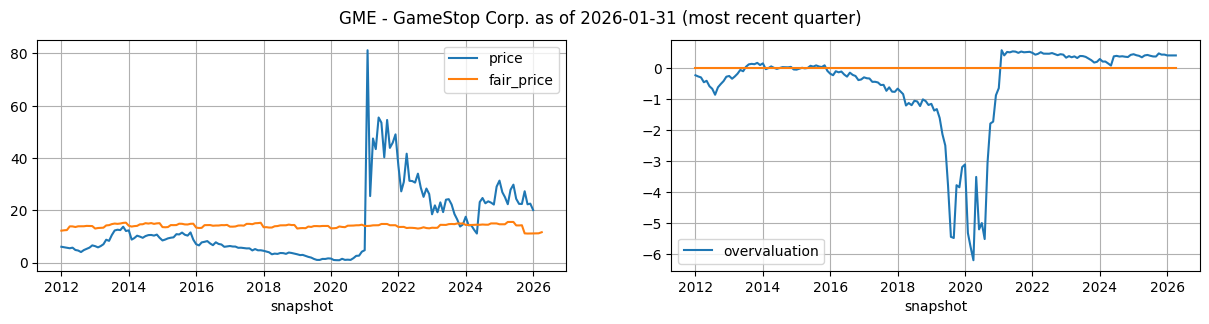

GME fair_price = 1.204565 * (0.000294 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.416930


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000294,1.529789,1.204565,16.41693,-4.351962,11.174709,0.409861
2026-02-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000294,1.529789,1.204565,16.41693,-4.351962,11.174709,0.409861
2026-03-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000294,1.529789,1.204565,16.41693,-4.351962,11.174709,0.409861
2026-04-01,0001326380,2026-01-31,GME,10.3884,4.9440,0.6148,0.000294,1.529789,1.204565,16.41693,-4.000427,11.598155,0.409861
2026-04-04,0001326380,2026-01-31,GME,10.3884,4.9440,0.6148,0.000294,1.529789,1.204565,16.41693,-4.000427,11.598155,0.409861


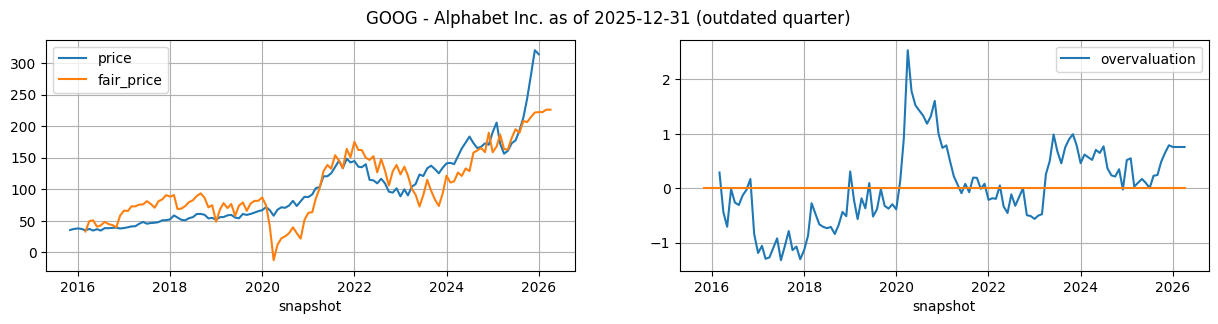

GOOG fair_price = 1.061023 * (0.232893 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.551477


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.232893,1.529789,1.061023,2.551477,206.984559,222.166935,0.75658
2026-02-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.232893,1.529789,1.061023,2.551477,206.984559,222.166935,0.75658
2026-03-01,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,0.232893,1.529789,1.061023,2.551477,210.596818,225.999626,0.75658
2026-04-01,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,0.232893,1.529789,1.061023,2.551477,210.596818,225.999626,0.75658
2026-04-04,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,0.232893,1.529789,1.061023,2.551477,210.596818,225.999626,0.75658


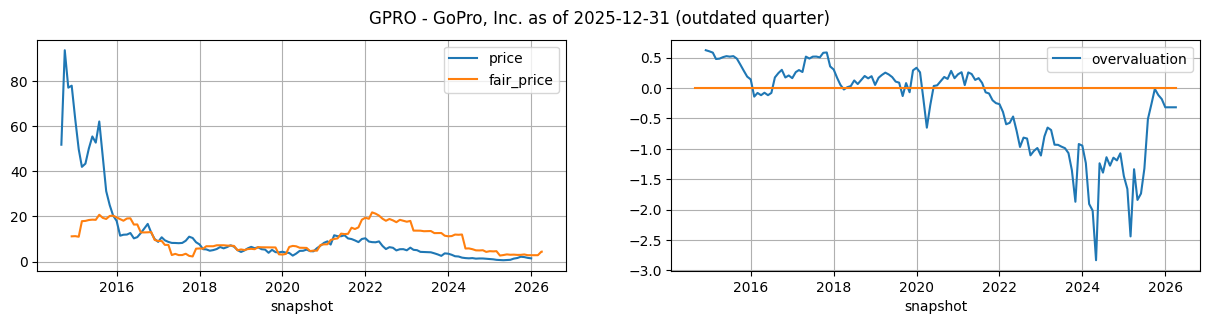

GPRO fair_price = 20.278173 * (0.822410 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.011779


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.82241,1.529789,20.278173,5.011779,-0.109042,2.800602,-0.316125
2026-02-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.82241,1.529789,20.278173,5.011779,-0.109042,2.800602,-0.316125
2026-03-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.82241,1.529789,20.278173,5.011779,-0.109042,2.800602,-0.316125
2026-04-01,0001500435,2025-12-31,GPRO,0.427983,0.351433,-0.020669,0.82241,1.529789,20.278173,5.011779,-0.031075,4.381639,-0.316125
2026-04-04,0001500435,2025-12-31,GPRO,0.427983,0.351433,-0.020669,0.82241,1.529789,20.278173,5.011779,-0.031075,4.381639,-0.316125


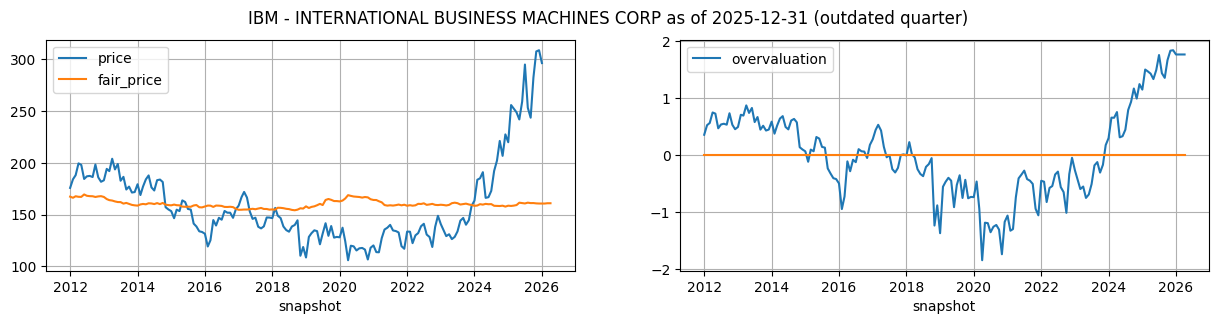

IBM fair_price = -0.233968 * (0.008704 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +138.138789


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.008704,1.529789,-0.233968,138.138789,-96.507375,160.718391,1.762437
2026-02-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.008704,1.529789,-0.233968,138.138789,-96.507375,160.718391,1.762437
2026-03-01,0000051143,2025-12-31,IBM,151.880,119.232,13.193,0.008704,1.529789,-0.233968,138.138789,-97.727551,161.003873,1.762437
2026-04-01,0000051143,2025-12-31,IBM,151.880,119.232,13.193,0.008704,1.529789,-0.233968,138.138789,-97.727551,161.003873,1.762437
2026-04-04,0000051143,2025-12-31,IBM,151.880,119.232,13.193,0.008704,1.529789,-0.233968,138.138789,-97.727551,161.003873,1.762437


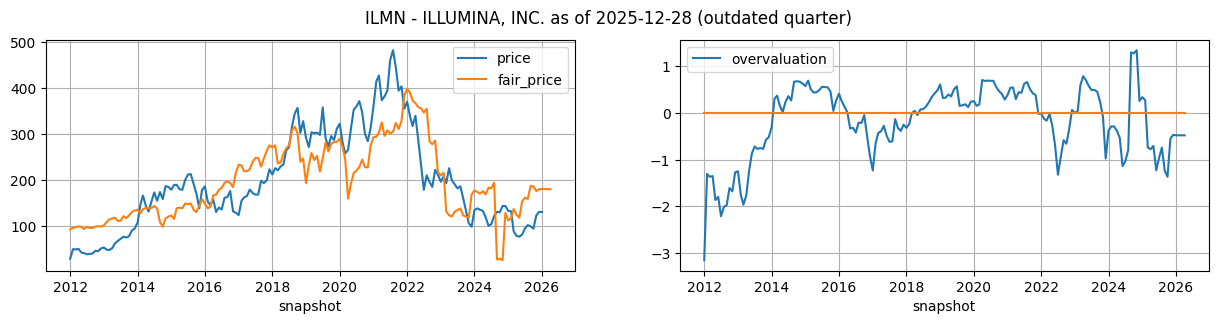

ILMN fair_price = 86.095695 * (0.397371 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +148.843600


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.397371,1.529789,86.095695,148.8436,0.374987,181.128325,-0.476143
2026-02-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.397371,1.529789,86.095695,148.8436,0.374987,181.128325,-0.476143
2026-03-01,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,0.397371,1.529789,86.095695,148.8436,0.369778,180.679896,-0.476143
2026-04-01,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,0.397371,1.529789,86.095695,148.8436,0.369778,180.679896,-0.476143
2026-04-04,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,0.397371,1.529789,86.095695,148.8436,0.369778,180.679896,-0.476143


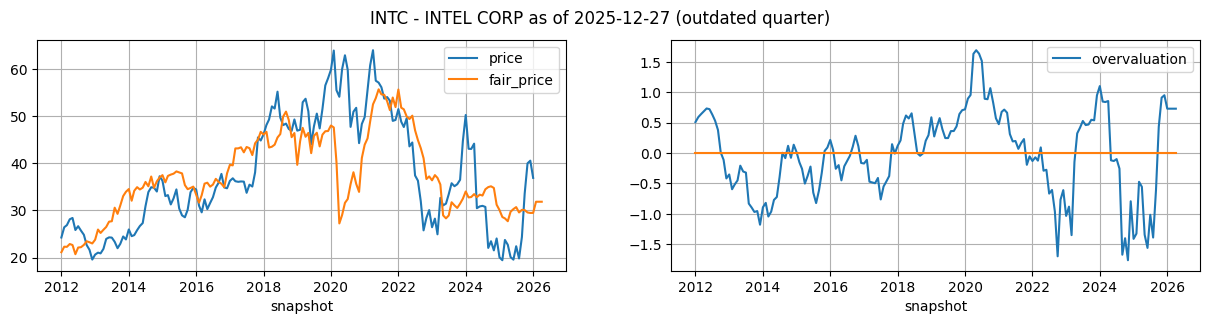

INTC fair_price = 0.418026 * (0.426947 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.517464


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.426947,1.529789,0.418026,28.517464,2.295106,29.476878,0.730378
2026-02-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.426947,1.529789,0.418026,28.517464,7.955399,31.843026,0.730378
2026-03-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.426947,1.529789,0.418026,28.517464,7.955399,31.843026,0.730378
2026-04-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.426947,1.529789,0.418026,28.517464,7.955399,31.843026,0.730378
2026-04-04,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.426947,1.529789,0.418026,28.517464,7.955399,31.843026,0.730378


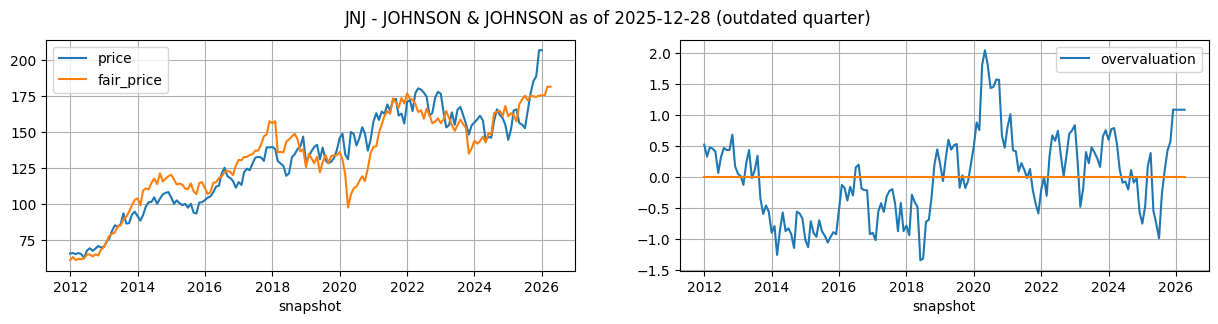

JNJ fair_price = 1.039497 * (1.471811 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -39.915951


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.47181,1.529789,1.039497,-39.915951,207.276601,175.547358,1.086753
2026-02-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.47181,1.529789,1.039497,-39.915951,207.276601,175.547358,1.086753
2026-03-01,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,1.47181,1.529789,1.039497,-39.915951,213.059067,181.558212,1.086753
2026-04-01,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,1.47181,1.529789,1.039497,-39.915951,213.059067,181.558212,1.086753
2026-04-04,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,1.47181,1.529789,1.039497,-39.915951,213.059067,181.558212,1.086753


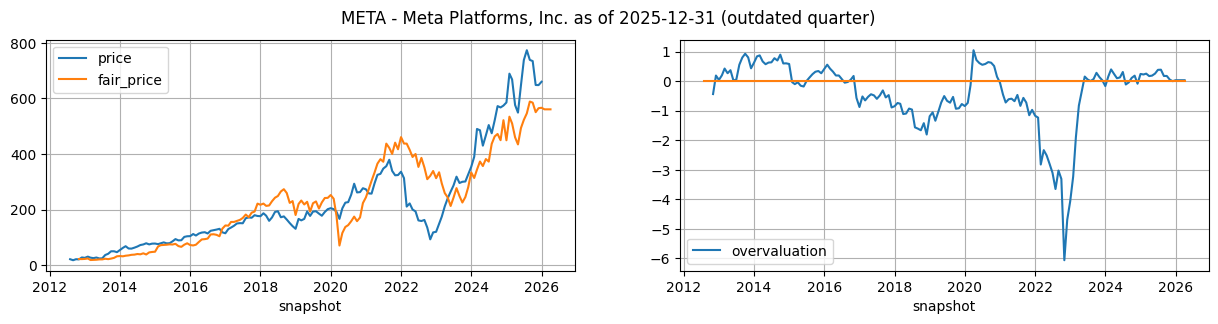

META fair_price = 3.150448 * (0.396432 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +14.292832


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.396432,1.529789,3.150448,14.292832,175.240997,566.380552,0.032436
2026-02-01,0001326801,2025-12-31,META,366.021,148.778,115.800,0.396432,1.529789,3.150448,14.292832,173.473988,560.813684,0.032436
2026-03-01,0001326801,2025-12-31,META,366.021,148.778,115.800,0.396432,1.529789,3.150448,14.292832,173.473988,560.813684,0.032436
2026-04-01,0001326801,2025-12-31,META,366.021,148.778,115.800,0.396432,1.529789,3.150448,14.292832,173.473988,560.813684,0.032436
2026-04-04,0001326801,2025-12-31,META,366.021,148.778,115.800,0.396432,1.529789,3.150448,14.292832,173.473988,560.813684,0.032436


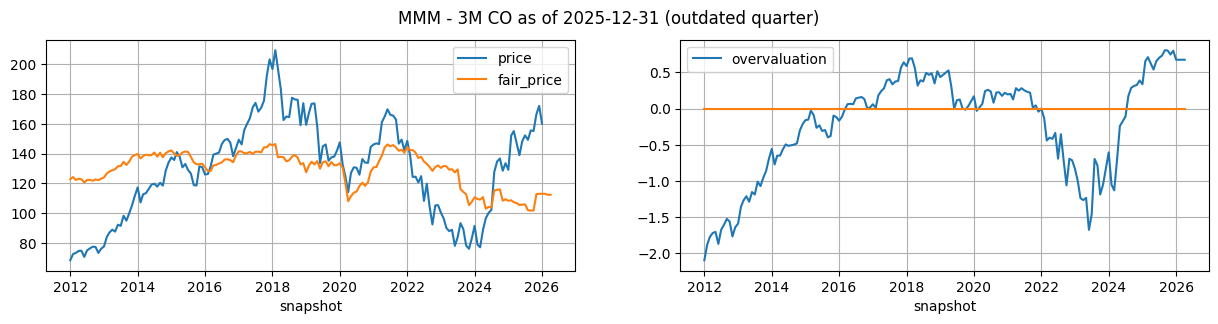

MMM fair_price = 1.868839 * (0.473237 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +134.103627


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.473237,1.529789,1.868839,134.103627,-11.296903,112.991530,0.676261
2026-02-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.473237,1.529789,1.868839,134.103627,-11.296903,112.991530,0.676261
2026-03-01,0000066740,2025-12-31,MMM,37.733,33.031,2.306,0.473237,1.529789,1.868839,134.103627,-11.646669,112.337875,0.676261
2026-04-01,0000066740,2025-12-31,MMM,37.733,33.031,2.306,0.473237,1.529789,1.868839,134.103627,-11.646669,112.337875,0.676261
2026-04-04,0000066740,2025-12-31,MMM,37.733,33.031,2.306,0.473237,1.529789,1.868839,134.103627,-11.646669,112.337875,0.676261


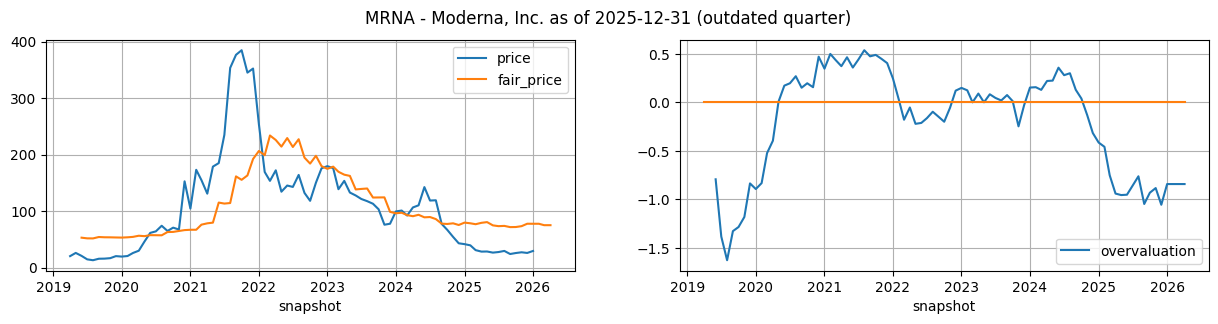

MRNA fair_price = 4.737181 * (0.940734 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.190617


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.940734,1.529789,4.737181,51.190617,5.584880,77.647204,-0.842943
2026-02-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.940734,1.529789,4.737181,51.190617,5.584880,77.647204,-0.842943
2026-03-01,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,0.940734,1.529789,4.737181,51.190617,5.053477,75.129851,-0.842943
2026-04-01,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,0.940734,1.529789,4.737181,51.190617,5.053477,75.129851,-0.842943
2026-04-04,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,0.940734,1.529789,4.737181,51.190617,5.053477,75.129851,-0.842943


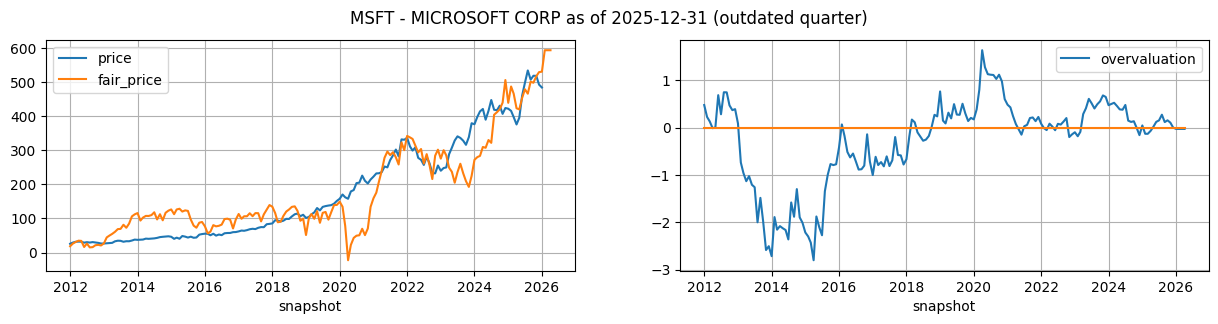

MSFT fair_price = 1.968279 * (0.430984 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +85.252331


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.430984,1.529789,1.968279,85.252331,225.920712,529.927288,-0.028523
2026-02-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,0.430984,1.529789,1.968279,85.252331,257.847798,592.768696,-0.028523
2026-03-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,0.430984,1.529789,1.968279,85.252331,257.847798,592.768696,-0.028523
2026-04-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,0.430984,1.529789,1.968279,85.252331,257.847798,592.768696,-0.028523
2026-04-04,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,0.430984,1.529789,1.968279,85.252331,257.847798,592.768696,-0.028523


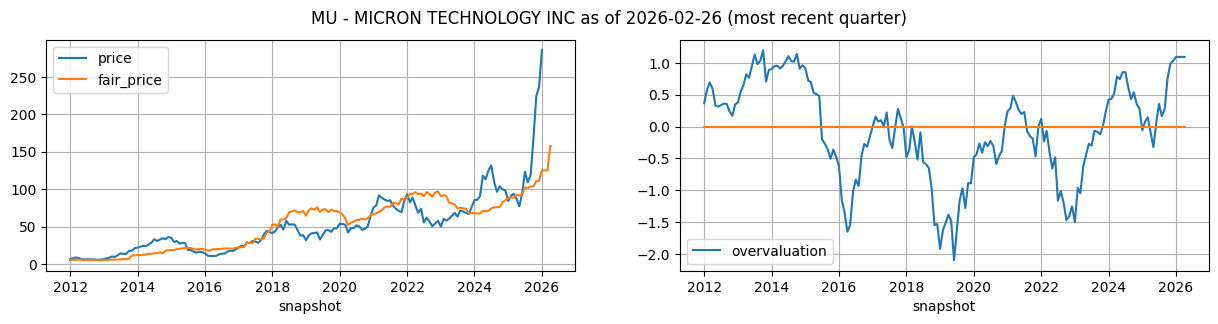

MU fair_price = 0.974674 * (1.490487 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.285048


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.490487,1.529789,0.974674,-7.285048,135.687612,124.966164,1.092383
2026-02-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.490487,1.529789,0.974674,-7.285048,135.687612,124.966164,1.092383
2026-03-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.490487,1.529789,0.974674,-7.285048,135.687612,124.966164,1.092383
2026-04-01,0000723125,2026-02-26,MU,101.509,29.050,30.653,1.490487,1.529789,0.974674,-7.285048,169.140447,157.571778,1.092383
2026-04-04,0000723125,2026-02-26,MU,101.509,29.050,30.653,1.490487,1.529789,0.974674,-7.285048,169.140447,157.571778,1.092383


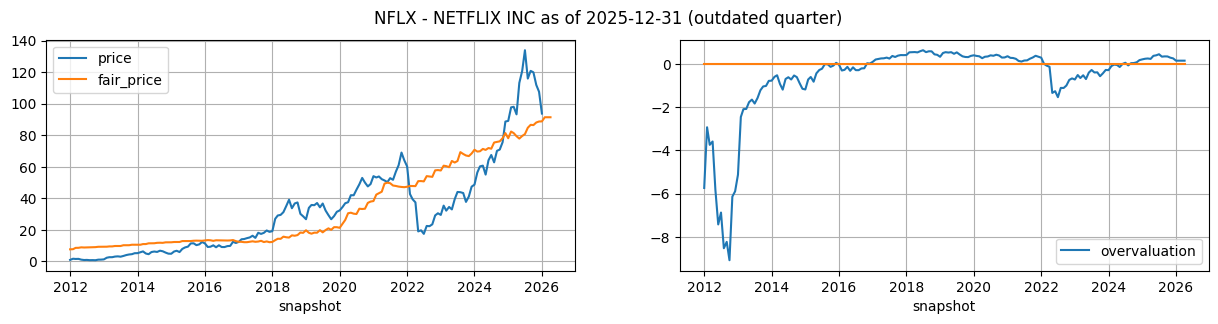

NFLX fair_price = 1.562287 * (1.213163 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +7.066721


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.213163,1.529789,1.562287,7.066721,52.311122,88.791680,0.149819
2026-02-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.213163,1.529789,1.562287,7.066721,53.992966,91.419202,0.149819
2026-03-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.213163,1.529789,1.562287,7.066721,53.992966,91.419202,0.149819
2026-04-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.213163,1.529789,1.562287,7.066721,53.992966,91.419202,0.149819
2026-04-04,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.213163,1.529789,1.562287,7.066721,53.992966,91.419202,0.149819


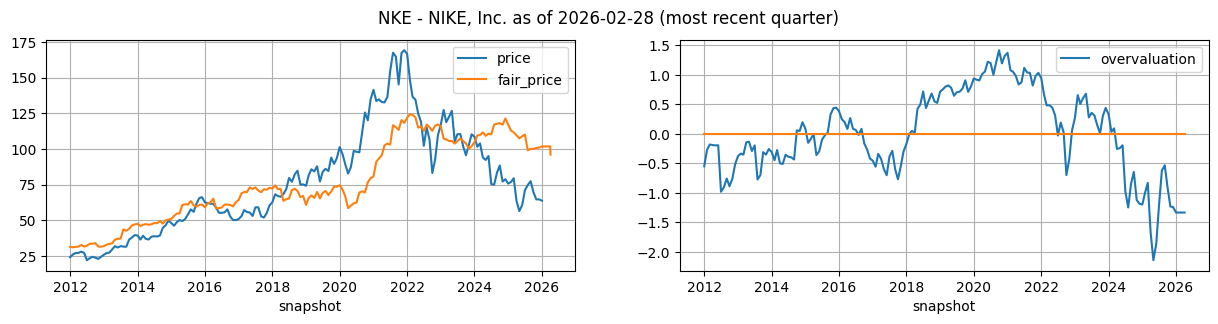

NKE fair_price = 2.024046 * (2.042384 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -15.943700


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.042384,1.529789,2.024046,-15.9437,58.148597,101.751760,-1.331628
2026-02-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.042384,1.529789,2.024046,-15.9437,58.148597,101.751760,-1.331628
2026-03-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.042384,1.529789,2.024046,-15.9437,58.148597,101.751760,-1.331628
2026-04-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.042384,1.529789,2.024046,-15.9437,58.148597,101.751760,-1.331628
2026-04-04,0000320187,2026-02-28,NKE,37.064,22.974,1.694,2.042384,1.529789,2.024046,-15.9437,55.316380,96.019222,-1.331628


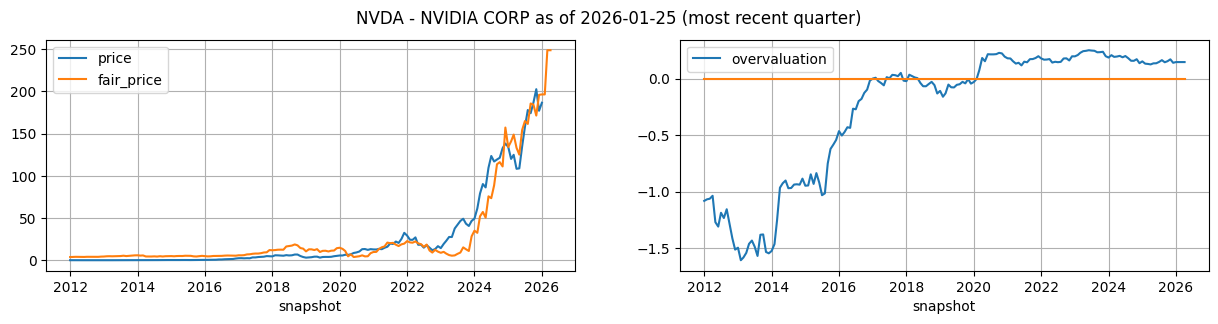

NVDA fair_price = 1.410967 * (0.314714 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +4.895537


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.314714,1.529789,1.410967,4.895537,135.680241,196.335818,0.145964
2026-02-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.314714,1.529789,1.410967,4.895537,135.680241,196.335818,0.145964
2026-03-01,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,0.314714,1.529789,1.410967,4.895537,172.710647,248.584481,0.145964
2026-04-01,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,0.314714,1.529789,1.410967,4.895537,172.710647,248.584481,0.145964
2026-04-04,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,0.314714,1.529789,1.410967,4.895537,172.710647,248.584481,0.145964


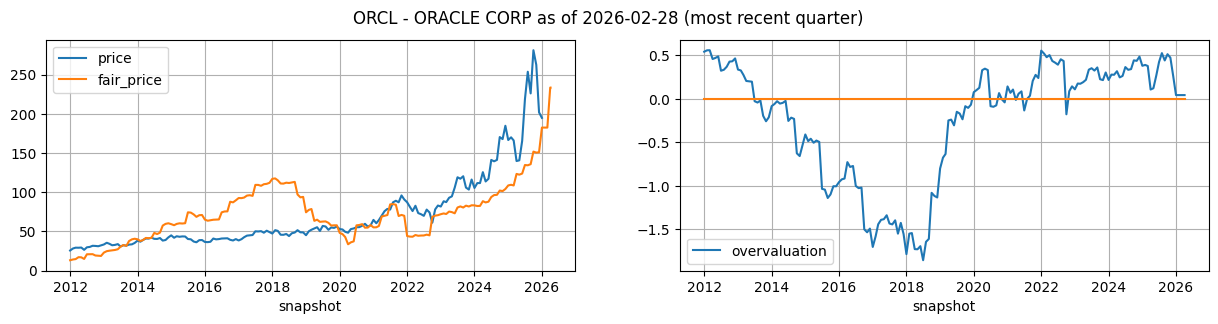

ORCL fair_price = 0.507173 * (3.242698 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -83.138632


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.242698,1.529789,0.507173,-83.138632,523.776475,182.506655,0.043863
2026-02-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.242698,1.529789,0.507173,-83.138632,523.776475,182.506655,0.043863
2026-03-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.242698,1.529789,0.507173,-83.138632,523.776475,182.506655,0.043863
2026-04-01,0001341439,2026-02-28,ORCL,245.240,206.745,23.514,3.242698,1.529789,0.507173,-83.138632,624.465827,233.573576,0.043863
2026-04-04,0001341439,2026-02-28,ORCL,245.240,206.745,23.514,3.242698,1.529789,0.507173,-83.138632,624.465827,233.573576,0.043863


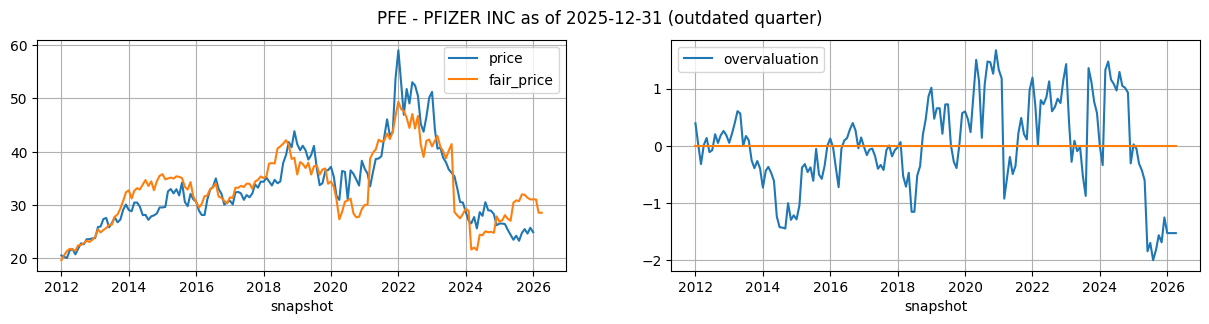

PFE fair_price = 0.318730 * (0.057021 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +57.851333


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.930,13.077,0.057021,1.529789,0.31873,57.851333,-84.022860,31.070686,-1.527864
2026-02-01,0000078003,2025-09-28,PFE,208.731,115.930,13.077,0.057021,1.529789,0.31873,57.851333,-84.022860,31.070686,-1.527864
2026-03-01,0000078003,2025-12-31,PFE,208.160,121.684,11.704,0.057021,1.529789,0.31873,57.851333,-91.909819,28.556872,-1.527864
2026-04-01,0000078003,2025-12-31,PFE,208.160,121.684,11.704,0.057021,1.529789,0.31873,57.851333,-91.909819,28.556872,-1.527864
2026-04-04,0000078003,2025-12-31,PFE,208.160,121.684,11.704,0.057021,1.529789,0.31873,57.851333,-91.909819,28.556872,-1.527864


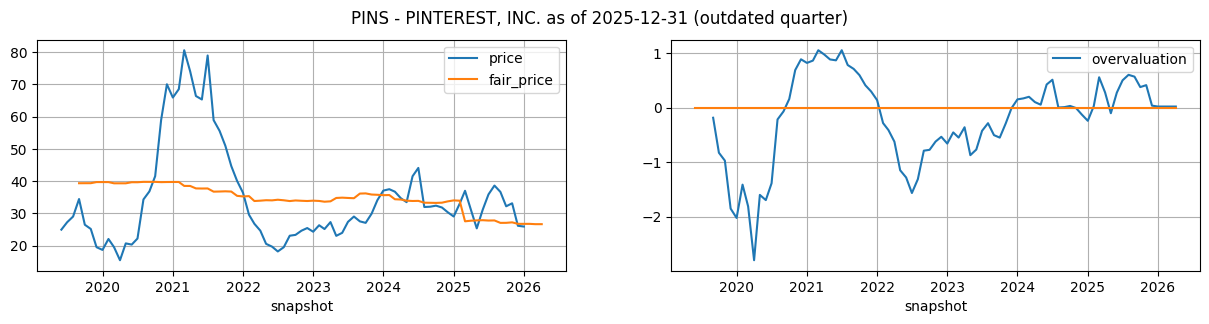

PINS fair_price = -1.137580 * (3.082632 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.270331


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.082632,1.529789,-1.13758,47.270331,18.066276,26.718497,0.018113
2026-02-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.082632,1.529789,-1.13758,47.270331,18.066276,26.718497,0.018113
2026-03-01,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,3.082632,1.529789,-1.13758,47.270331,18.147981,26.625551,0.018113
2026-04-01,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,3.082632,1.529789,-1.13758,47.270331,18.147981,26.625551,0.018113
2026-04-04,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,3.082632,1.529789,-1.13758,47.270331,18.147981,26.625551,0.018113


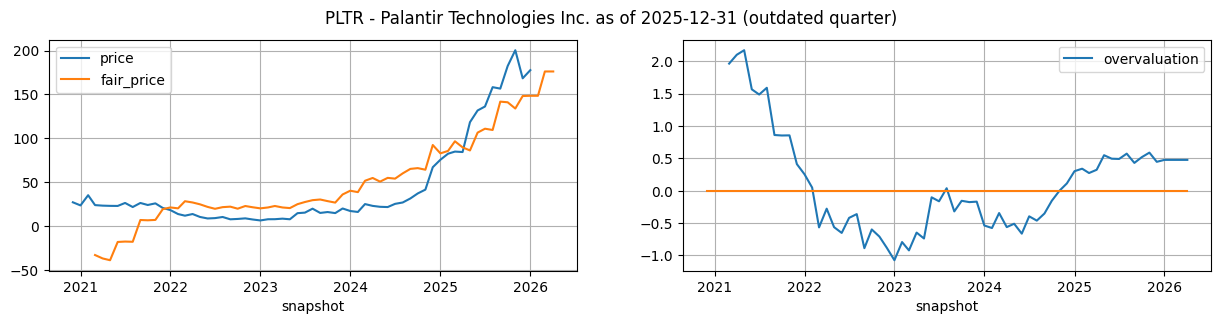

PLTR fair_price = 34.536711 * (0.390812 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.394406


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.390812,1.529789,34.536711,-4.394406,4.427932,148.531809,0.476471
2026-02-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.390812,1.529789,34.536711,-4.394406,4.427932,148.531809,0.476471
2026-03-01,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,0.390812,1.529789,34.536711,-4.394406,5.230553,176.251684,0.476471
2026-04-01,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,0.390812,1.529789,34.536711,-4.394406,5.230553,176.251684,0.476471
2026-04-04,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,0.390812,1.529789,34.536711,-4.394406,5.230553,176.251684,0.476471


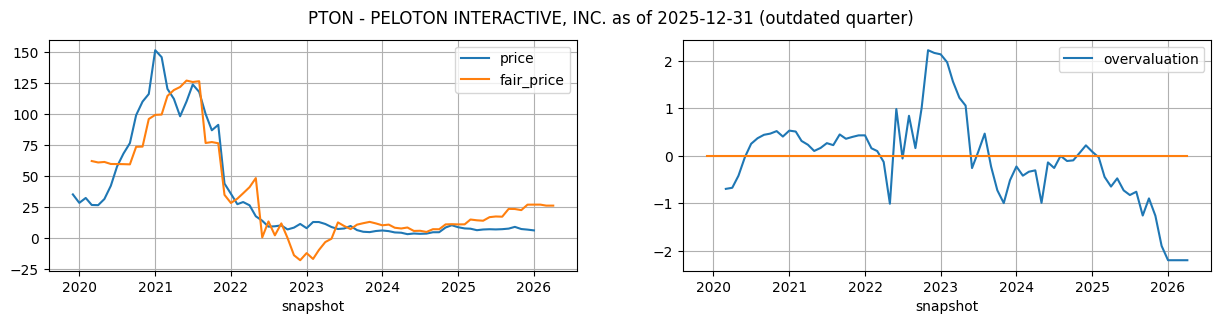

PTON fair_price = 22.825408 * (1.491286 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -3.131476


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.491286,1.529789,22.825408,-3.131476,1.319429,26.985031,-2.199949
2026-02-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.491286,1.529789,22.825408,-3.131476,1.319429,26.985031,-2.199949
2026-03-01,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,1.491286,1.529789,22.825408,-3.131476,1.283790,26.171563,-2.199949
2026-04-01,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,1.491286,1.529789,22.825408,-3.131476,1.283790,26.171563,-2.199949
2026-04-04,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,1.491286,1.529789,22.825408,-3.131476,1.283790,26.171563,-2.199949


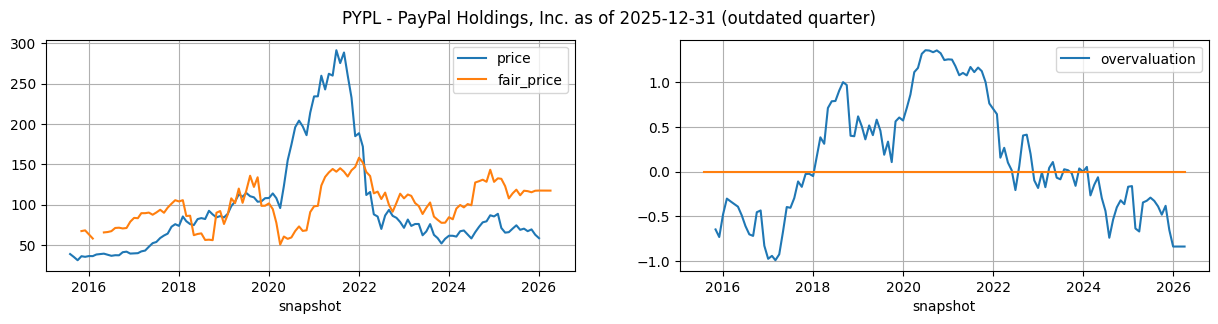

PYPL fair_price = 7.051740 * (0.861853 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -16.580198


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.861853,1.529789,7.05174,-16.580198,19.004119,117.431901,-0.839694
2026-02-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.861853,1.529789,7.05174,-16.580198,19.004119,117.431901,-0.839694
2026-03-01,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,0.861853,1.529789,7.05174,-16.580198,18.995430,117.370631,-0.839694
2026-04-01,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,0.861853,1.529789,7.05174,-16.580198,18.995430,117.370631,-0.839694
2026-04-04,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,0.861853,1.529789,7.05174,-16.580198,18.995430,117.370631,-0.839694


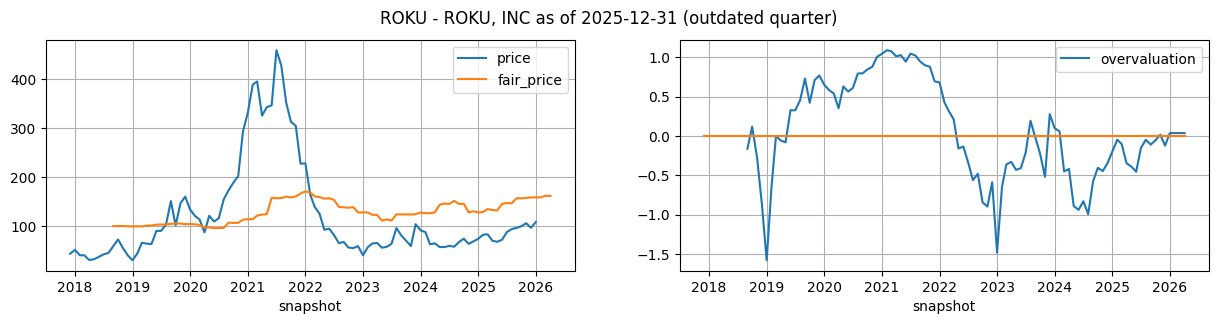

ROKU fair_price = 53.480353 * (0.496249 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +99.727113


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.496249,1.529789,53.480353,99.727113,1.106554,158.906035,0.036664
2026-02-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.496249,1.529789,53.480353,99.727113,1.106554,158.906035,0.036664
2026-03-01,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,0.496249,1.529789,53.480353,99.727113,1.164560,162.008216,0.036664
2026-04-01,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,0.496249,1.529789,53.480353,99.727113,1.164560,162.008216,0.036664
2026-04-04,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,0.496249,1.529789,53.480353,99.727113,1.164560,162.008216,0.036664


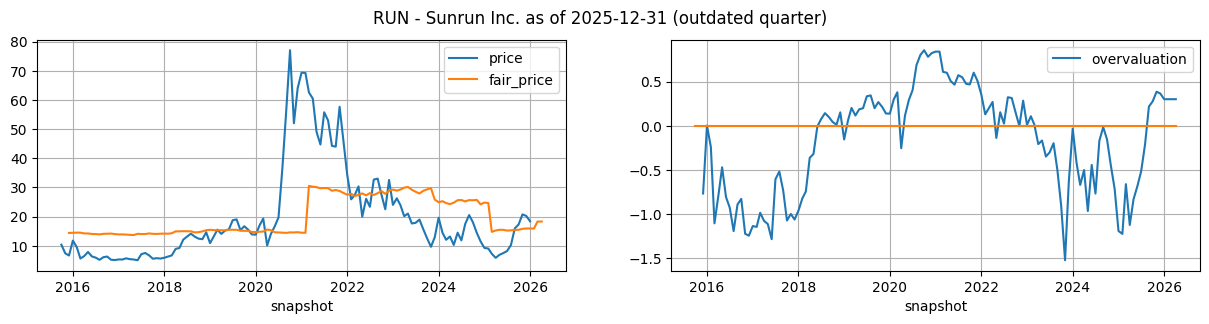

RUN fair_price = 3.533854 * (0.956291 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.003456


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.956291,1.529789,3.533854,13.003456,0.824183,15.915998,0.300608
2026-02-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.956291,1.529789,3.533854,13.003456,0.824183,15.915998,0.300608
2026-03-01,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,0.956291,1.529789,3.533854,13.003456,1.499477,18.302388,0.300608
2026-04-01,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,0.956291,1.529789,3.533854,13.003456,1.499477,18.302388,0.300608
2026-04-04,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,0.956291,1.529789,3.533854,13.003456,1.499477,18.302388,0.300608


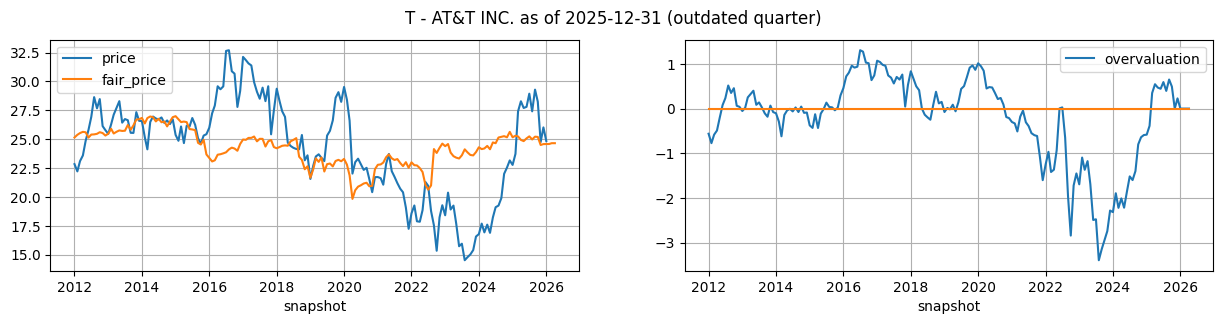

T fair_price = 0.044480 * (0.096237 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.175929


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.096237,1.529789,0.04448,33.175929,-193.222043,24.581337,-0.0
2026-02-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.096237,1.529789,0.04448,33.175929,-193.222043,24.581337,-0.0
2026-03-01,0000732717,2025-12-31,T,420.198,293.707,40.284,0.096237,1.529789,0.04448,33.175929,-191.642356,24.651602,-0.0
2026-04-01,0000732717,2025-12-31,T,420.198,293.707,40.284,0.096237,1.529789,0.04448,33.175929,-191.642356,24.651602,-0.0
2026-04-04,0000732717,2025-12-31,T,420.198,293.707,40.284,0.096237,1.529789,0.04448,33.175929,-191.642356,24.651602,-0.0


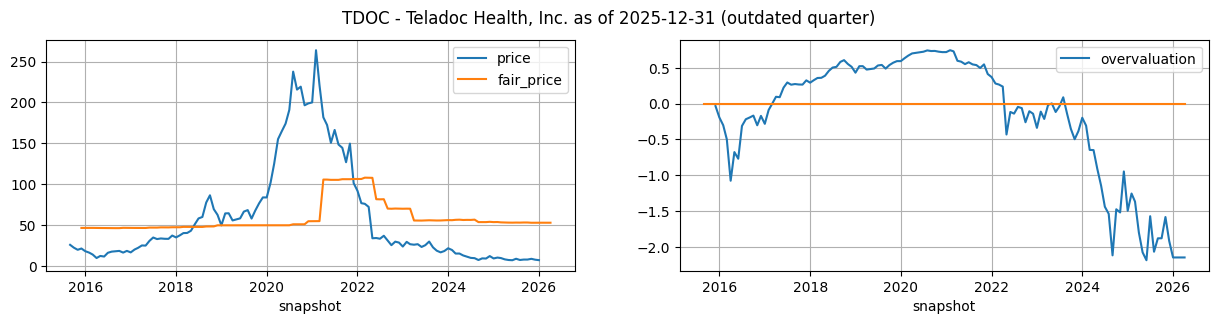

TDOC fair_price = 3.742057 * (1.010543 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.808458


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.010543,1.529789,3.742057,45.808458,1.869952,52.805924,-2.14615
2026-02-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.010543,1.529789,3.742057,45.808458,1.869952,52.805924,-2.14615
2026-03-01,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,1.010543,1.529789,3.742057,45.808458,1.866144,52.791675,-2.14615
2026-04-01,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,1.010543,1.529789,3.742057,45.808458,1.866144,52.791675,-2.14615
2026-04-04,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,1.010543,1.529789,3.742057,45.808458,1.866144,52.791675,-2.14615


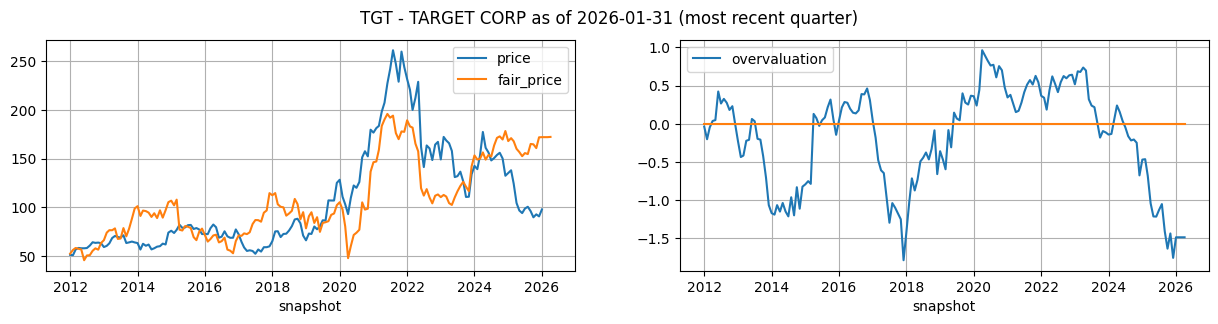

TGT fair_price = 5.047320 * (1.584231 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -135.547705


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.584231,1.529789,5.04732,-135.547705,60.912402,171.896693,-1.487521
2026-02-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.584231,1.529789,5.04732,-135.547705,60.912402,171.896693,-1.487521
2026-03-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.584231,1.529789,5.04732,-135.547705,60.912402,171.896693,-1.487521
2026-04-01,0000027419,2026-01-31,TGT,59.490,43.325,6.562,1.584231,1.529789,5.04732,-135.547705,60.959387,172.133840,-1.487521
2026-04-04,0000027419,2026-01-31,TGT,59.490,43.325,6.562,1.584231,1.529789,5.04732,-135.547705,60.959387,172.133840,-1.487521


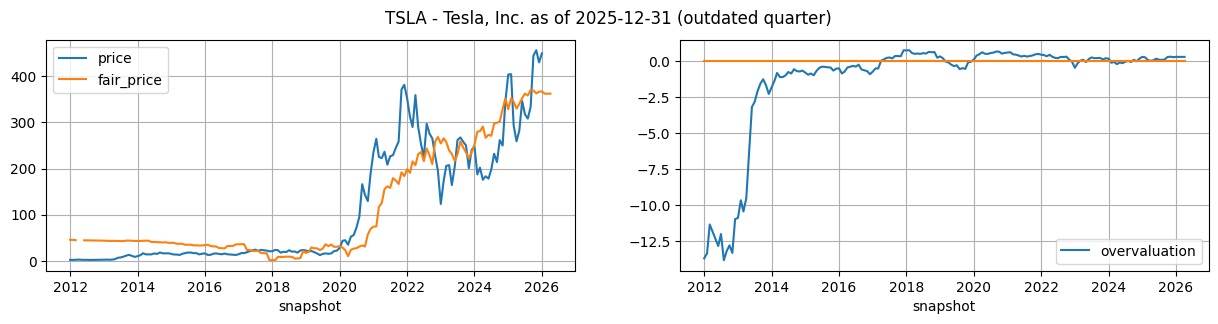

TSLA fair_price = 5.775535 * (0.640145 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +44.025332


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.640145,1.529789,5.775535,44.025332,55.935928,367.085245,0.275567
2026-02-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,0.640145,1.529789,5.775535,44.025332,55.106640,362.295662,0.275567
2026-03-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,0.640145,1.529789,5.775535,44.025332,55.106640,362.295662,0.275567
2026-04-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,0.640145,1.529789,5.775535,44.025332,55.106640,362.295662,0.275567
2026-04-04,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,0.640145,1.529789,5.775535,44.025332,55.106640,362.295662,0.275567


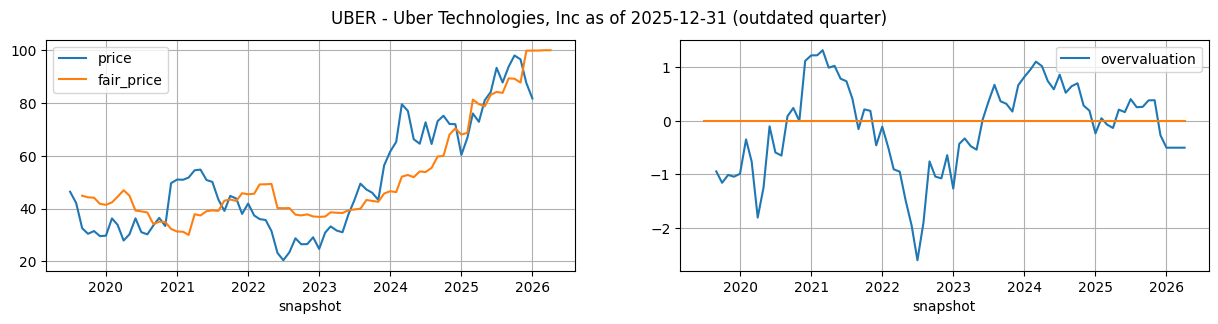

UBER fair_price = 1.373259 * (1.353095 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +11.649748


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.353095,1.529789,1.373259,11.649748,64.216566,99.835755,-0.501003
2026-02-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.353095,1.529789,1.373259,11.649748,64.216566,99.835755,-0.501003
2026-03-01,0001543151,2025-12-31,UBER,61.802,34.761,10.099,1.353095,1.529789,1.373259,11.649748,64.312344,99.967284,-0.501003
2026-04-01,0001543151,2025-12-31,UBER,61.802,34.761,10.099,1.353095,1.529789,1.373259,11.649748,64.312344,99.967284,-0.501003
2026-04-04,0001543151,2025-12-31,UBER,61.802,34.761,10.099,1.353095,1.529789,1.373259,11.649748,64.312344,99.967284,-0.501003


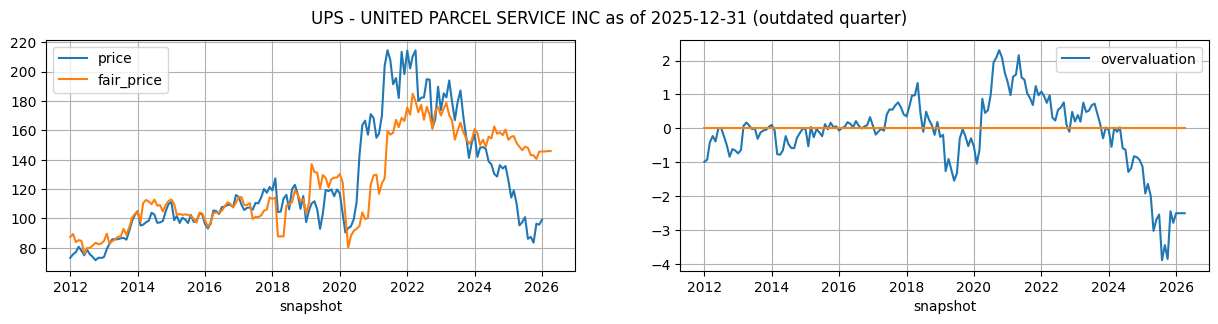

UPS fair_price = 2.744708 * (0.835512 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +98.888109


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.835512,1.529789,2.744708,98.888109,17.026456,145.620759,-2.498244
2026-02-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.835512,1.529789,2.744708,98.888109,17.026456,145.620759,-2.498244
2026-03-01,0001090727,2025-12-31,UPS,73.090,56.863,8.450,0.835512,1.529789,2.744708,98.888109,17.131268,145.908436,-2.498244
2026-04-01,0001090727,2025-12-31,UPS,73.090,56.863,8.450,0.835512,1.529789,2.744708,98.888109,17.131268,145.908436,-2.498244
2026-04-04,0001090727,2025-12-31,UPS,73.090,56.863,8.450,0.835512,1.529789,2.744708,98.888109,17.131268,145.908436,-2.498244


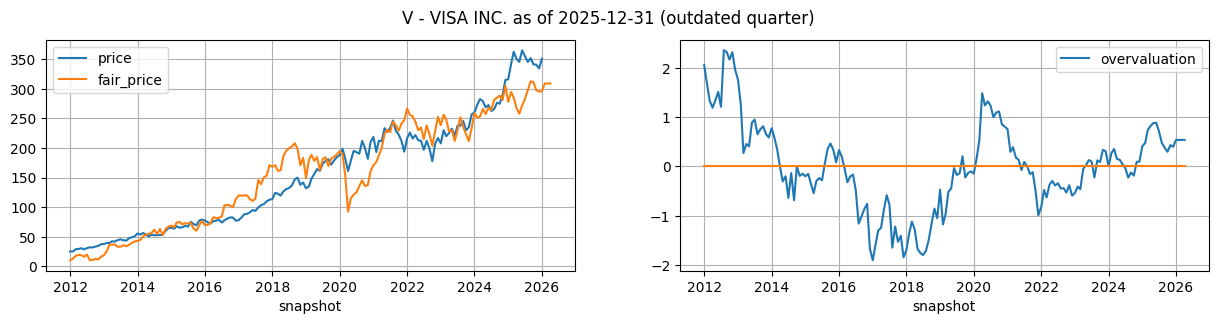

V fair_price = 4.890766 * (1.108742 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -115.043523


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.108742,1.529789,4.890766,-115.043523,84.018025,295.868996,0.537984
2026-02-01,0001403161,2025-12-31,V,96.814,58.037,24.443,1.108742,1.529789,4.890766,-115.043523,86.697362,308.973010,0.537984
2026-03-01,0001403161,2025-12-31,V,96.814,58.037,24.443,1.108742,1.529789,4.890766,-115.043523,86.697362,308.973010,0.537984
2026-04-01,0001403161,2025-12-31,V,96.814,58.037,24.443,1.108742,1.529789,4.890766,-115.043523,86.697362,308.973010,0.537984
2026-04-04,0001403161,2025-12-31,V,96.814,58.037,24.443,1.108742,1.529789,4.890766,-115.043523,86.697362,308.973010,0.537984


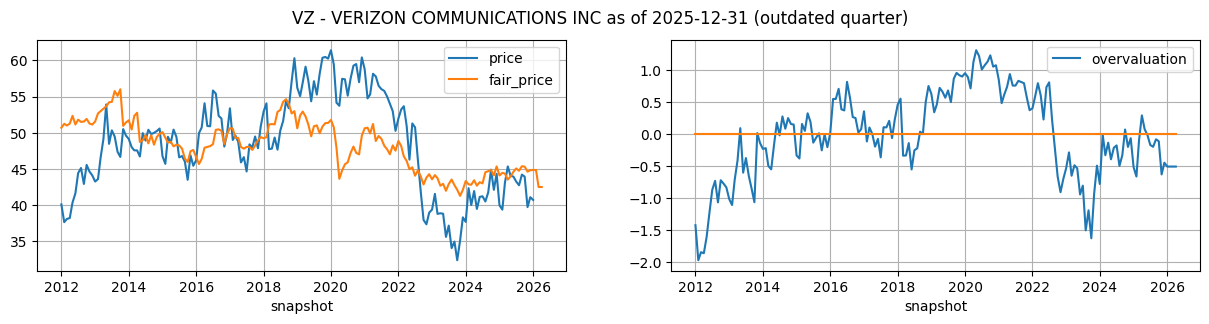

VZ fair_price = 0.128059 * (0.013091 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +72.791212


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013091,1.529789,0.128059,72.791212,-218.074231,44.864821,-0.502587
2026-02-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013091,1.529789,0.128059,72.791212,-218.074231,44.864821,-0.502587
2026-03-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,0.013091,1.529789,0.128059,72.791212,-236.412990,42.516376,-0.502587
2026-04-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,0.013091,1.529789,0.128059,72.791212,-236.412990,42.516376,-0.502587
2026-04-04,0000732712,2025-12-31,VZ,404.258,298.517,37.137,0.013091,1.529789,0.128059,72.791212,-236.412990,42.516376,-0.502587


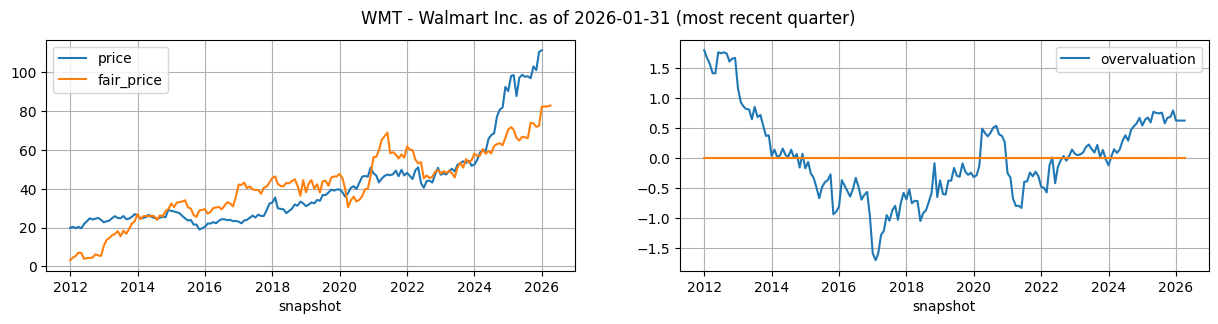

WMT fair_price = 0.407780 * (1.792299 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -75.606510


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.792299,1.529789,0.40778,-75.60651,387.481215,82.400697,0.628125
2026-02-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.792299,1.529789,0.40778,-75.60651,387.481215,82.400697,0.628125
2026-03-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.792299,1.529789,0.40778,-75.60651,387.481215,82.400697,0.628125
2026-04-01,0000104169,2026-01-31,WMT,284.668,185.051,41.565,1.792299,1.529789,0.40778,-75.60651,388.744835,82.915976,0.628125
2026-04-04,0000104169,2026-01-31,WMT,284.668,185.051,41.565,1.792299,1.529789,0.40778,-75.60651,388.744835,82.915976,0.628125


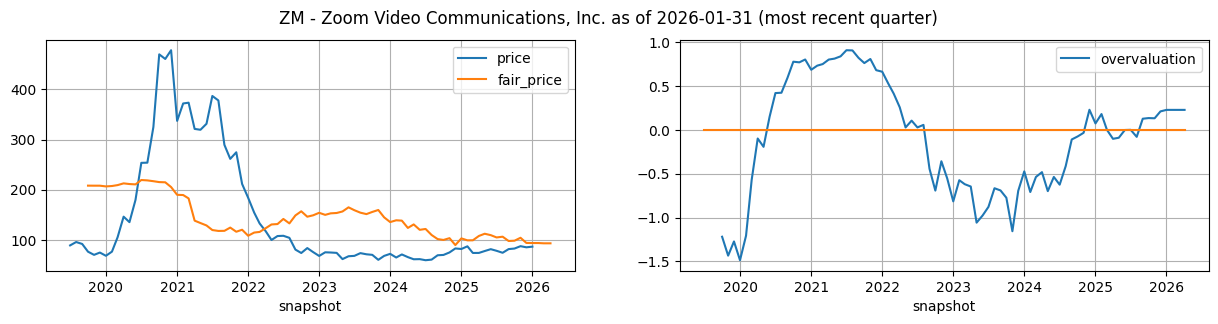

ZM fair_price = -25.684087 * (0.309453 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +210.874331


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.309453,1.529789,-25.684087,210.874331,4.570928,93.474229,0.227573
2026-02-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.309453,1.529789,-25.684087,210.874331,4.570928,93.474229,0.227573
2026-03-01,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,0.309453,1.529789,-25.684087,210.874331,4.591853,92.936793,0.227573
2026-04-01,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,0.309453,1.529789,-25.684087,210.874331,4.591853,92.936793,0.227573
2026-04-04,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,0.309453,1.529789,-25.684087,210.874331,4.591853,92.936793,0.227573


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['fair_price'] = df['fair_model'] * df['slope'] + df['intercept']
    df['overvaluation'] = (df['fair_price']/df['price']).interpolate()
    df['overvaluation'] = -1 * preprocessing.RobustScaler().fit_transform(df['overvaluation'].to_frame())

    months_since_last_report = (datetime.today() - pd.to_datetime(df['date'].max())) / timedelta(days=30)
    caption = f"{ticker} - {name}"
    caption += f" as of {df['date'].max()} ({"most recent" if months_since_last_report<3 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['slope'].mean(), df['asmul'].mean(),
        "+" if df['intercept'].mean() >= 0 else "", df['intercept'].mean()
    ))

    # Display a few most recent records from the resultset
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [18]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.917721
fair_price  0.917721    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.013091,-1.175388,-172.512516,0.128059,72.791212,-172.512516,50.699413,-1.419388
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.013091,-1.033792,-168.298461,0.128059,72.791212,-168.298461,51.239062,-1.967037
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.013091,-0.959121,-170.098594,0.128059,72.791212,-170.098594,51.008538,-1.842022
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.013091,-0.890643,-168.059346,0.128059,72.791212,-168.059346,51.269682,-1.856887
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.013091,-0.914941,-159.672199,0.128059,72.791212,-159.672199,52.343733,-1.603592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,40.73,0.013091,1.529789,-218.074231,0.128059,72.791212,-218.074231,44.864821,-0.502587
2026-02-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,NaN,0.013091,1.529789,NaN,0.128059,72.791212,-218.074231,44.864821,-0.502587
2026-03-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,NaN,0.013091,1.529789,NaN,0.128059,72.791212,-236.412990,42.516376,-0.502587


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

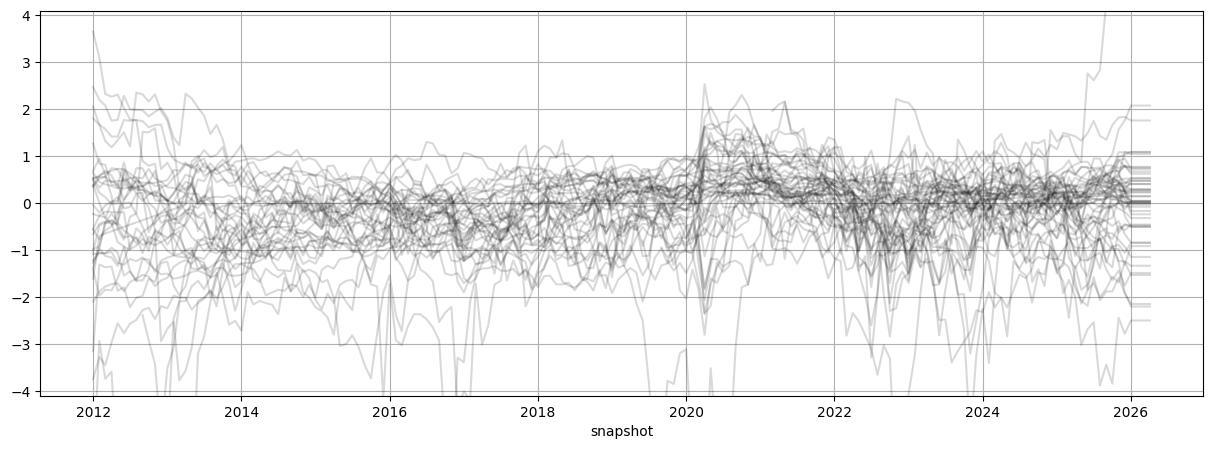

In [19]:
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, c='black', alpha=0.15, figsize=(15,5),ylim=(-4.1,4.1))
plt.show()

In [20]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.